# 01. Análise Exploratória

**Fase CRISP-DM:** 2, *Data Understanding*.
**Entregável:** relatório de exploração e de qualidade de dados, com achados numerados, impacto e ação recomendada para a engenharia de features e para a modelagem.

Este notebook narra a análise. Toda a lógica mora em [`src/eda.py`](../src/eda.py), e a leitura das bases em [`src/data/loader.py`](../src/data/loader.py).

Cada item existe para fechar uma decisão concreta das etapas seguintes.

| Pergunta | Decisão que ela sustenta |
|---|---|
| O alvo é desbalanceado? | usar ou não reamostragem |
| Quais colunas têm variância / sinal? | lista de features do modelo |
| Onde estão os nulos e por quê? | estratégia de imputação e `add_indicator` |
| O lag de 2023 prediz 2024? | existência do modelo |
| Em que grão o sinal vive: aluno, escola ou município? | esquema de validação e camada estratégica |
| Onde há risco de vazamento? | matriz anti-leakage |

> **Revisão 2026-09-05:** evidência retrospectiva e exploratória. A seleção histórica consultou a coorte inteira. Não há teste independente da seleção nem validação temporal do campeão. Consulte `reports/revisao_cientifica.md` e `reports/contrato_temporal.md`.


In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib
import numpy as np
import pandas as pd
import sklearn

# O notebook roda a partir de notebooks/, mas importa o pacote src/ da raiz.
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))

from src import config, eda
from src.data import loader

eda.aplicar_estilo()
warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

print("interpretador", sys.executable)
print("python      ", sys.version.split()[0])
print("pandas      ", pd.__version__)
print("numpy       ", np.__version__)
print("scikit-learn", sklearn.__version__)
print("matplotlib  ", matplotlib.__version__)
print("RANDOM_STATE", config.RANDOM_STATE)

interpretador C:\Users\Vyctor\Documents\pos-tech\fase-3\Fase3_TechChallenge-Predicao-Inteligencia-Analitica-para-Alfabetizacao-no-Brasil\.venv\Scripts\python.exe
python       3.14.3
pandas       2.3.3
numpy        2.4.3
scikit-learn 1.8.0
matplotlib   3.10.9
RANDOM_STATE 42


## Carga das bases

Quatro insumos, todos lidos do Parquet de `data/interim/`. Os CSVs de 615 MB e 214 MB não são abertos aqui.

| Base | Papel |
|---|---|
| Gold 2024 | coorte e alvo do modelo |
| Gold 2023 | comparação do alvo entre anos |
| microdado 2023 | fonte **exclusiva** das features de lag, por conter `proficiencia` e os ausentes |
| microdado 2024 | reconciliação, viés de ausência e persistência, nunca como feature |

In [2]:
gold_2023 = loader.carregar_gold(2023)
gold_2024 = loader.carregar_gold(2024)
aluno_2023 = loader.carregar_aluno(2023)
aluno_2024 = loader.carregar_aluno(2024)
dim_municipio = loader.carregar_dim_municipio()

presentes_2023 = aluno_2023[aluno_2023["presenca"] == 1]
presentes_2024 = aluno_2024[aluno_2024["presenca"] == 1]

resumo_carga = pd.DataFrame(
    [
        {"base": "Gold 2023 (presenca=1)", "linhas": len(gold_2023), "colunas": gold_2023.shape[1]},
        {"base": "Gold 2024 (presenca=1)", "linhas": len(gold_2024), "colunas": gold_2024.shape[1]},
        {"base": "microdado 2023 (todos)", "linhas": len(aluno_2023), "colunas": aluno_2023.shape[1]},
        {"base": "microdado 2024 (todos)", "linhas": len(aluno_2024), "colunas": aluno_2024.shape[1]},
        {"base": "dim_municipio", "linhas": len(dim_municipio), "colunas": dim_municipio.shape[1]},
    ]
)
print(resumo_carga.to_string(index=False))
print()
print("reconciliação Gold 2024 x microdado 2024 (presentes):", len(gold_2024) == len(presentes_2024))
print("memória aproximada em uso (MB):", round(sum(d.memory_usage(deep=False).sum() for d in [gold_2023, gold_2024, aluno_2023, aluno_2024]) / 2**20))

                  base  linhas  colunas
Gold 2023 (presenca=1) 1503058       21
Gold 2024 (presenca=1) 1852788       21
microdado 2023 (todos) 1747439       12
microdado 2024 (todos) 2120560       12
         dim_municipio    5547        5

reconciliação Gold 2024 x microdado 2024 (presentes): True
memória aproximada em uso (MB): 404


---
## 1. Distribuição do alvo, global e por ano

**Pergunta:** a base é desbalanceada a ponto de exigir reamostragem?
**Decisão que depende disso:** usar ou não SMOTE e `class_weight` agressivo na modelagem.

,ano,n_alunos,n_alfabetizados,taxa_alfabetizado,taxa_risco,ic_low,ic_high
0,2023,1503058,877427,0.5838,0.4162,0.5830,0.5845
1,2024,1852788,1107119,0.5975,0.4025,0.5968,0.5982


images/eda/01_distribuicao_target_por_ano.png


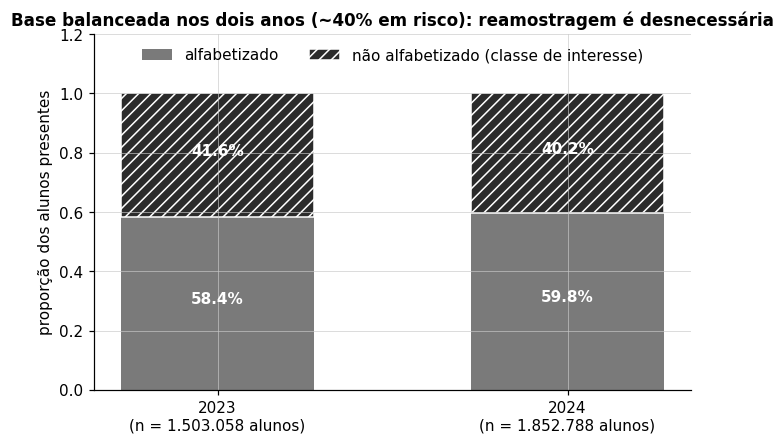

In [3]:
alvo_por_ano = eda.medir_target_por_ano({2023: gold_2023["alfabetizado"], 2024: gold_2024["alfabetizado"]})
display(alvo_por_ano.round(4))

fig = eda.plotar_target_por_ano(alvo_por_ano)
print(eda.salvar_figura(fig, "01_distribuicao_target_por_ano"))

**Achado 1.** São 59,75% de alfabetizados em 2024 (IC 95% [59,68%; 59,82%]) e 58,38% em 2023. A classe de interesse, *não alfabetizado*, tem prevalência de **40,25%**. Isso é praticamente equilibrado.

Não haverá reamostragem. SMOTE ou `class_weight="balanced"` distorceriam a calibração das probabilidades, e é justamente a probabilidade calibrada que a camada estratégica precisa para ranquear municípios. O alvo será invertido (`risco_nao_alfabetizacao = 1 - alfabetizado`) para que a classe de interesse seja a positiva, e a prevalência de referência do PR-AUC passa a ser 0,403.

A alta de 1,4pp entre 2023 e 2024 é pequena, mas real: os ICs não se tocam. Ela vem acompanhada de uma alta na taxa de presença, medida no item 18. Mais alunos avaliados, taxa maior.

---
## 2. Cardinalidade e variância de cada coluna

**Pergunta:** que colunas não têm variância, quais são identificadores e quais são categóricas de verdade?
**Decisão:** a lista de features do modelo e o que vai para `config.COLS_PROIBIDAS`.

,coluna,dtype,n_unicos,pct_nulo,memoria_mb,exemplo
0,ano,int16,1,0.00,3.534039,2024
1,serie,int8,1,0.00,1.767082,2
2,serie_nome,object,1,0.00,14.135777,2º ano do Ensino Fundamental
3,percentual_participacao_brasil,float32,1,0.00,7.067951,87.370003
4,meta_alfabetizacao_brasil,float32,1,0.00,7.067951,59.900002
5,alfabetizado,int8,2,0.00,1.767082,0
6,preenchimento_caderno,float32,2,0.00,7.067951,1.0
7,rede,int8,3,0.00,1.767082,3
8,rede_nome,object,3,0.00,14.135777,Municipal
9,nome_regiao,object,5,0.00,14.135777,Nordeste


images/eda/02_cardinalidade_colunas_gold.png


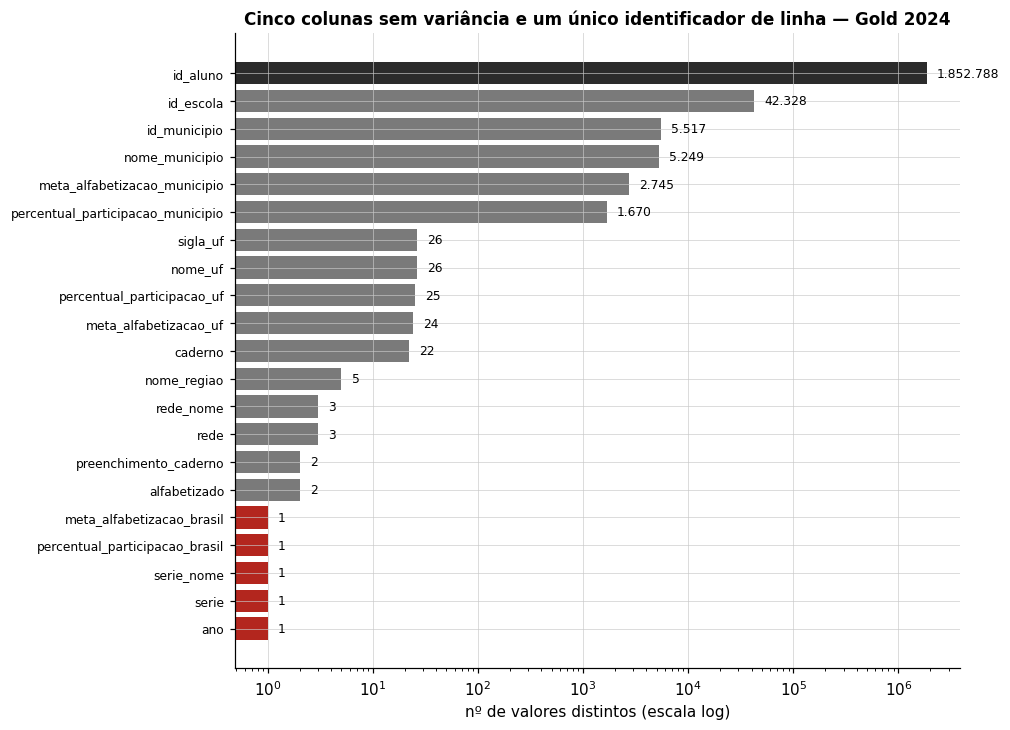

In [4]:
estrutura_gold = eda.medir_estrutura(gold_2024)
display(estrutura_gold.assign(pct_nulo=lambda d: (d["pct_nulo"] * 100).round(2)))

fig = eda.plotar_cardinalidade(estrutura_gold, "Cinco colunas sem variância e um único identificador de linha — Gold 2024", len(gold_2024))
print(eda.salvar_figura(fig, "02_cardinalidade_colunas_gold"))

In [5]:
constantes = estrutura_gold.loc[estrutura_gold["n_unicos"] <= 1, "coluna"].tolist()
identificadores = estrutura_gold.loc[estrutura_gold["n_unicos"] > 0.5 * len(gold_2024), "coluna"].tolist()
print("cardinalidade 1 (sem variância):", constantes)
print("identificadores de linha       :", identificadores)
print()
print("microdado 2023 — estrutura:")
display(eda.medir_estrutura(aluno_2023).assign(pct_nulo=lambda d: (d["pct_nulo"] * 100).round(2)))

cardinalidade 1 (sem variância): ['ano', 'serie', 'serie_nome', 'percentual_participacao_brasil', 'meta_alfabetizacao_brasil']
identificadores de linha       : ['id_aluno']

microdado 2023 — estrutura:


,coluna,dtype,n_unicos,pct_nulo,memoria_mb,exemplo
0,ano,int16,1,0.0,3.333101,2.023000e+03
1,serie,int8,1,0.0,1.666614,2.000000e+00
2,rede,int8,2,0.0,1.666614,3.000000e+00
3,presenca,int8,2,0.0,1.666614,0.000000e+00
4,alfabetizado,int8,2,0.0,1.666614,0.000000e+00
5,preenchimento_caderno,int8,2,0.0,1.666614,0.000000e+00
6,caderno,int8,21,0.0,1.666614,1.000000e+00
7,id_municipio,int32,4873,0.0,6.666077,2.918407e+06
8,id_escola,int32,36776,0.0,6.666077,6.001508e+07
9,peso_aluno,float32,69398,14.0,6.666077,5.053508e-01


**Achado 2.** Cinco colunas da Gold têm cardinalidade 1 em 2024: `ano`, `serie`, `serie_nome`, `meta_alfabetizacao_brasil` e `percentual_participacao_brasil`. As três últimas são constantes *dentro do ano*. Elas variam entre anos, mas o modelo treina só em 2024, então para ele são constantes do mesmo jeito. Já `id_aluno` tem 1.852.788 valores distintos para 1.852.788 linhas: é identificador de linha, não variável.

Saem `serie` e `serie_nome`, que já estavam em `config.COLS_PROIBIDAS`, e também as duas colunas de Brasil, que o plano ainda não listava. Constante não informa nada e ainda ocupa espaço no `ColumnTransformer`. Restam como candidatas categóricas reais `rede` (3 níveis), `nome_regiao` (5), `sigla_uf` (26) e `caderno` (22).

---
## 3. Taxa por `caderno`, o controle negativo

**Pergunta:** o caderno de prova, que é randomizado entre alunos, carrega sinal?
**Decisão:** o plano prevê mantê-lo no modelo como **controle negativo**. Se ele aparecer com importância alta na leitura de interpretabilidade, isso é alarme de sobreajuste. Antes de usá-lo assim, é preciso provar que ele não separa o alvo.

,caderno,n,k,taxa,ic_low,ic_high,amplitude_ic
0,1,97195,57897,0.5957,0.5926,0.5988,0.0062
1,2,93330,55360,0.5932,0.5900,0.5963,0.0063
2,3,93402,55469,0.5939,0.5907,0.5970,0.0063
3,4,93291,55895,0.5991,0.5960,0.6023,0.0063
4,5,93388,56239,0.6022,0.5991,0.6053,0.0063
5,6,93092,55902,0.6005,0.5974,0.6036,0.0063
6,7,93102,55825,0.5996,0.5965,0.6028,0.0063
7,8,86365,52154,0.6039,0.6006,0.6071,0.0065
8,9,85346,50938,0.5968,0.5935,0.6001,0.0066
9,10,85440,51477,0.6025,0.5992,0.6058,0.0066


entre os 21 cadernos regulares: {'n_niveis': 21, 'taxa_min': 0.5869414596911514, 'taxa_max': 0.6044262621763237, 'amplitude_taxas_pp': 1.7484802485172257, 'maior_ic_low': 0.601140344803217, 'menor_ic_high': 0.5902446176770322, 'todos_ics_se_sobrepoem': False}

AUC do caderno codificado pela própria taxa (in-sample, o melhor caso possível): 0.5056
cadernos em 2023: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21]
cadernos em 2024: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 43]


images/eda/03_taxa_por_caderno.png


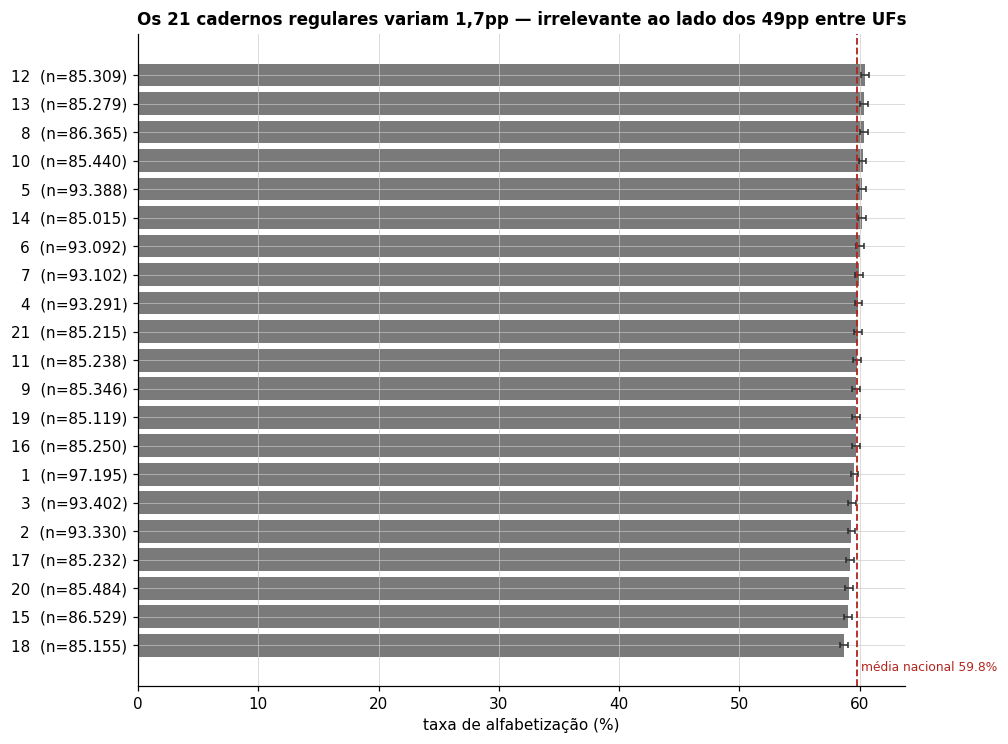

In [6]:
taxa_caderno = eda.medir_taxa_por_categoria(gold_2024, "caderno")
display(taxa_caderno.round(4))

sobreposicao = eda.medir_sobreposicao_ic(taxa_caderno[taxa_caderno["n"] > 1_000])
print("entre os 21 cadernos regulares:", sobreposicao)

taxa_por_nivel = gold_2024.groupby("caderno")["alfabetizado"].mean()
auc_caderno = eda.auc_univariada(gold_2024["alfabetizado"].to_numpy(), gold_2024["caderno"].map(taxa_por_nivel).to_numpy())
print(f"\nAUC do caderno codificado pela própria taxa (in-sample, o melhor caso possível): {auc_caderno:.4f}")
print("cadernos em 2023:", sorted(aluno_2023['caderno'].unique().tolist()))
print("cadernos em 2024:", sorted(gold_2024['caderno'].unique().tolist()))

fig = eda.plotar_taxa_por_categoria(
    taxa_caderno[taxa_caderno["n"] > 1_000],
    "caderno",
    "Os 21 cadernos regulares variam 1,7pp — irrelevante ao lado dos 49pp entre UFs",
    linha_referencia=float(gold_2024["alfabetizado"].mean()),
    ordenar=True,
)
print(eda.salvar_figura(fig, "03_taxa_por_caderno"))

**Achado 3, com uma ressalva contra o plano.** A amplitude entre os 21 cadernos regulares é de **1,75pp** (58,69% a 60,44%). Codificando o caderno pela sua própria taxa, que é o cenário mais favorável possível por ser medido dentro da amostra, a **AUC é 0,506**. Como preditor, isso é acaso.

O teste de sobreposição de intervalos, porém, falha. Com cerca de 85 mil alunos por caderno, o IC do caderno 12 (60,11% a 60,77%) e o do caderno 18 (58,36% a 59,02%) não se tocam. A diferença é estatisticamente significante e praticamente irrelevante, o caso clássico de significância sem relevância. Fica o registro porque o plano afirmava que os ICs se sobrepunham, e não é verdade. O argumento correto não é "não há diferença", é que a diferença vale 1,7pp contra 49pp entre UFs, com AUC de 0,506.

**Achado 3b, categoria rara e nova.** Existe um `caderno = 43` com **12 alunos** em 2024 que não existe em 2023. É exatamente o caso que quebra um `OneHotEncoder` ingênuo em produção.

O `caderno` fica como controle negativo, com `OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=0.01)`, o que agrupa o caderno 43 sozinho. O teste de invariância previsto para a modelagem continua valendo.

---
## 4. Taxa por região e por UF

**Pergunta:** qual o tamanho da desigualdade territorial?
**Decisão:** se o território dominar, ele define o esquema de validação e a estratégia de encoding.

,nome_regiao,n,k,taxa,ic_low,ic_high,amplitude_ic
0,Centro-Oeste,175459,113353,0.6460,0.6438,0.6483,0.0045
1,Nordeste,465987,264668,0.5680,0.5666,0.5694,0.0028
2,Norte,188119,95483,0.5076,0.5053,0.5098,0.0045
3,Sudeste,744675,463862,0.6229,0.6218,0.6240,0.0022
4,Sul,278548,169753,0.6094,0.6076,0.6112,0.0036


amplitude entre regiões (pp): 13.85
amplitude entre UFs (pp)    : 49.37
razão maior/menor UF        : 2.373


AUC in-sample de nome_regiao: 0.5423


AUC in-sample de sigla_uf: 0.6304
images/eda/04_taxa_por_regiao.png


images/eda/04_taxa_por_uf.png


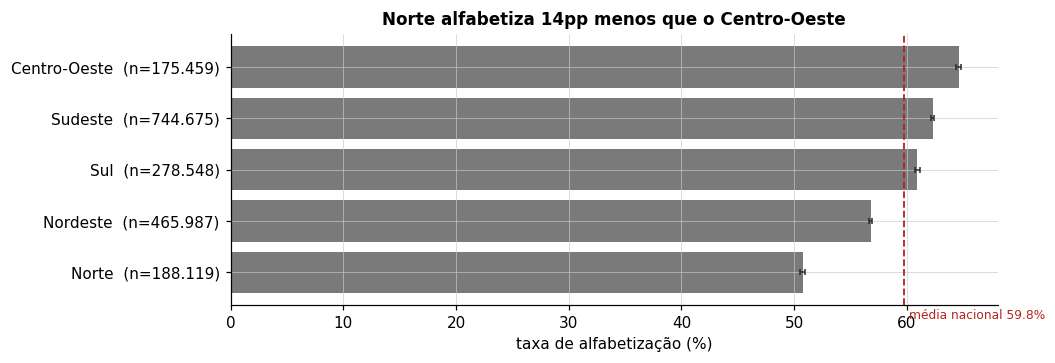

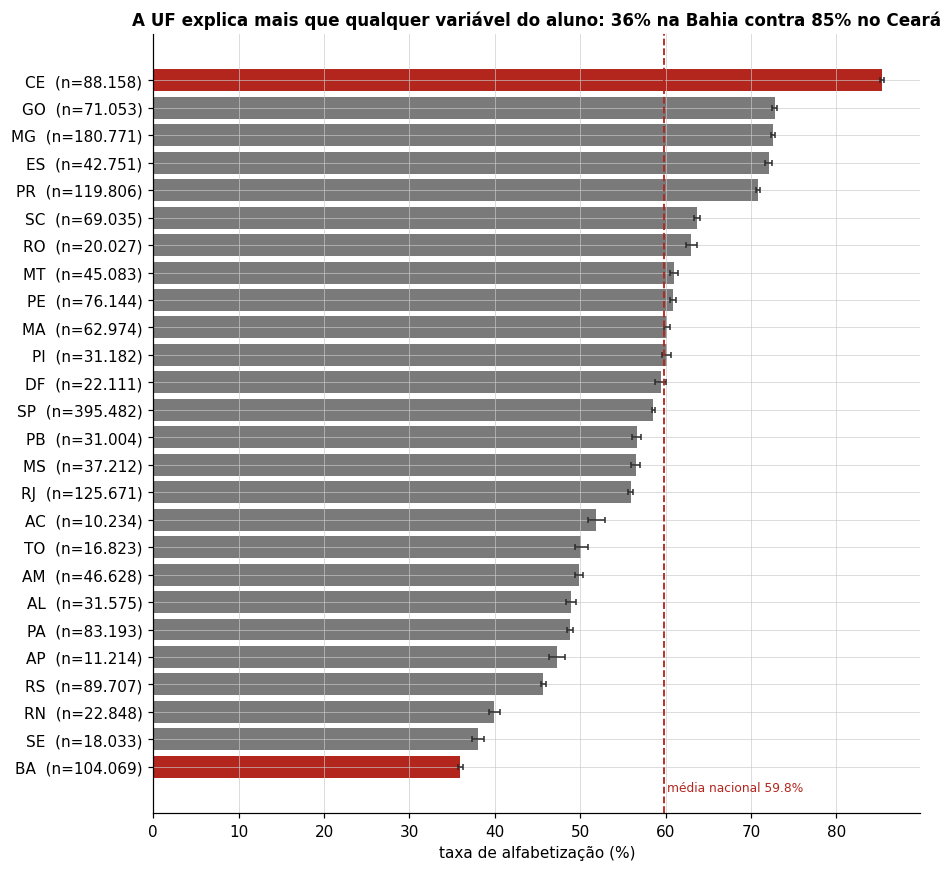

In [7]:
taxa_regiao = eda.medir_taxa_por_categoria(gold_2024, "nome_regiao")
taxa_uf = eda.medir_taxa_por_categoria(gold_2024, "sigla_uf")
display(taxa_regiao.round(4))

media_nacional = float(gold_2024["alfabetizado"].mean())
print("amplitude entre regiões (pp):", round((taxa_regiao['taxa'].max() - taxa_regiao['taxa'].min()) * 100, 2))
print("amplitude entre UFs (pp)    :", round((taxa_uf['taxa'].max() - taxa_uf['taxa'].min()) * 100, 2))
print("razão maior/menor UF        :", round(taxa_uf['taxa'].max() / taxa_uf['taxa'].min(), 3))

for coluna in ["nome_regiao", "sigla_uf"]:
    taxa = gold_2024.groupby(coluna)["alfabetizado"].mean()
    escore = gold_2024[coluna].map(taxa).to_numpy()
    print(f"AUC in-sample de {coluna}: {eda.auc_univariada(gold_2024['alfabetizado'].to_numpy(), escore):.4f}")

fig = eda.plotar_taxa_por_categoria(taxa_regiao, "nome_regiao", "Norte alfabetiza 14pp menos que o Centro-Oeste", linha_referencia=media_nacional)
print(eda.salvar_figura(fig, "04_taxa_por_regiao"))

fig = eda.plotar_taxa_por_categoria(
    taxa_uf, "sigla_uf", "A UF explica mais que qualquer variável do aluno: 36% na Bahia contra 85% no Ceará",
    linha_referencia=media_nacional, destacar=["CE", "BA"],
)
print(eda.salvar_figura(fig, "04_taxa_por_uf"))

**Achado 4.** Entre regiões a amplitude é de 13,8pp, do Norte com 50,8% ao Centro-Oeste com 64,6%. Entre UFs ela chega a **49,4pp**: Bahia com 35,96% contra Ceará com 85,33%, uma razão de 2,37 vezes. A UF sozinha, codificada pela própria taxa, dá **AUC 0,630**; a região fica em 0,542.

Esse é o fato estruturante do projeto. A variável mais informativa desta base é onde a criança mora, e ela não descreve a criança.

Duas decisões saem daqui, e uma delas contraria o plano original. A primeira é manter `sigla_uf` como categórica one-hot: 26 níveis não justificam `TargetEncoder`, e `uf_taxa_alfab_lag1` já é o target encoding correto, defasado no tempo. A correção já estava registrada no plano e a medição a sustenta. A segunda é agrupar por município na validação cruzada. Com sinal territorial dessa magnitude, um `KFold` aleatório deixaria o modelo memorizar o nível de cada município e inflaria a métrica. O custo dessa honestidade já foi medido no diagnóstico inicial: 0,018 de AUC.

Fica um cuidado a declarar. O Ceará tem 85% de alfabetização e 98% de presença, medida no item 18, e esse é o extremo de uma correlação entre quem é avaliado e qual taxa se mede. Nenhuma leitura causal do tipo "o Ceará faz melhor política" se sustenta apenas com estes dados.

---
## 5. Taxa por rede e por preenchimento do caderno

**Pergunta:** a rede administrativa separa o alvo? E `preenchimento_caderno`, prevista no plano como feature de engajamento?

,rede,n,k,taxa,ic_low,ic_high,amplitude_ic
0,2,241173,150760,0.6251,0.6232,0.6270,0.0039
1,3,1611591,956343,0.5934,0.5927,0.5942,0.0015
2,4,24,16,0.6667,0.4671,0.8203,0.3532


,preenchimento_caderno,n,k,taxa,ic_low,ic_high,amplitude_ic
0,0.0,936,0,0.0000,0.0000,0.0041,0.0041
1,1.0,1851852,1107119,0.5978,0.5971,0.5986,0.0014


images/eda/05_taxa_por_rede.png


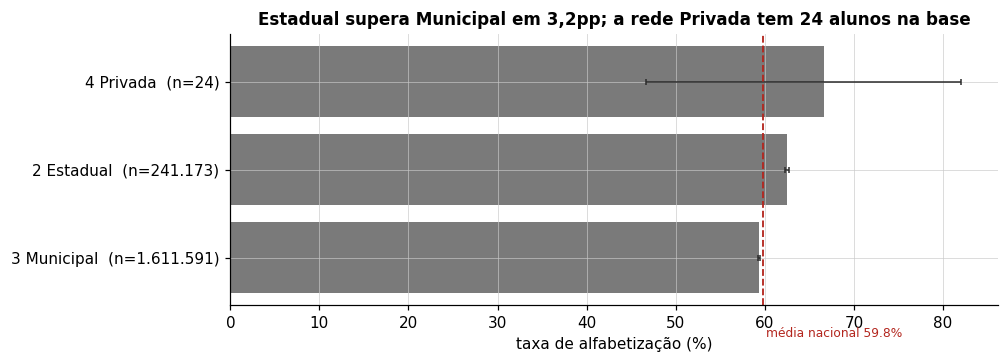

In [8]:
taxa_rede = eda.medir_taxa_por_categoria(gold_2024, "rede")
display(taxa_rede.round(4))
display(eda.medir_taxa_por_categoria(gold_2024, "preenchimento_caderno").round(4))

fig = eda.plotar_taxa_por_categoria(
    taxa_rede.assign(rede=lambda d: d["rede"].map({2: "2 Estadual", 3: "3 Municipal", 4: "4 Privada"})),
    "rede", "Estadual supera Municipal em 3,2pp; a rede Privada tem 24 alunos na base",
    linha_referencia=media_nacional,
)
print(eda.salvar_figura(fig, "05_taxa_por_rede"))

In [9]:
# `preenchimento_caderno = 0` merece uma investigação separada: é o único bloco da Gold
# com taxa de alfabetização exatamente zero.
sem_preenchimento = gold_2024[gold_2024["preenchimento_caderno"] == 0]
print("alunos com preenchimento_caderno = 0 na Gold 2024:", len(sem_preenchimento))
print("taxa de alfabetização nesse grupo:", sem_preenchimento["alfabetizado"].mean())
print()
print("presentes de 2024 sem proficiência medida:", int(presentes_2024["proficiencia"].isna().sum()))
print("desses, com preenchimento_caderno = 0    :", int(((presentes_2024["preenchimento_caderno"] == 0) & presentes_2024["proficiencia"].isna()).sum()))
print("mesmo bloco em 2023                      :", int(presentes_2023["proficiencia"].isna().sum()))

alunos com preenchimento_caderno = 0 na Gold 2024: 936
taxa de alfabetização nesse grupo: 0.0

presentes de 2024 sem proficiência medida: 936
desses, com preenchimento_caderno = 0    : 936
mesmo bloco em 2023                      : 249


**Achado 5.** Estadual com 62,51% contra Municipal com 59,34%, uma diferença de 3,2pp com ICs disjuntos, sendo que a rede Municipal concentra 87% dos alunos. A rede Privada tem **24 alunos** e IC de [46,7%; 82,0%]. Não é uma categoria, é um resíduo. A `rede` fica, agrupando Privada em "Outros", ou deixando o `min_frequency` do encoder fazer isso.

**Achado 6, armadilha nova que o plano não previa.** Os alunos com `preenchimento_caderno = 0` são **936, ou 0,05% da base, e 100% deles têm `alfabetizado = 0`**. São exatamente os presentes sem proficiência medida. O alvo deles é 0 por ausência de medida, não por medida. É o mesmo mecanismo dos `presenca = 0` que a Gold já filtrou, só que sobreviveu ao filtro. Em 2023 o bloco equivalente tem 249 alunos.

Há um problema adicional, e ele vale mesmo fora desse bloco. O `preenchimento_caderno` é registrado no mesmo instante da prova que produz o alvo, o que faz dele uma variável contemporânea ao desfecho, não anterior a ele. Como preditora, viola o requisito de anterioridade temporal que o resto do desenho respeita.

Daí saem duas ações para a engenharia de features. As 936 linhas saem do treino, porque alvo não observado não é alvo 0. E `preenchimento_caderno` sai da lista de features, indo para a matriz anti-leakage como vazamento contemporâneo. O impacto na métrica é desprezível, já que são 0,05% das linhas, mas o argumento metodológico não é.

---
## 6. Mapa de nulos por coluna e por ano

**Pergunta:** os nulos são falha de coleta ou ausência estrutural?
**Decisão:** média simples, ou imputação com indicador?

,coluna,Gold 2023,Gold 2024
14,meta_alfabetizacao_municipio,1.0000,0.1529
15,percentual_participacao_municipio,0.1159,0.1421
16,meta_alfabetizacao_uf,1.0000,0.0175
17,percentual_participacao_uf,0.0000,0.0000
18,meta_alfabetizacao_brasil,1.0000,0.0000
19,percentual_participacao_brasil,0.0000,0.0000


,coluna,microdado 2023,microdado 2024
10,proficiencia,0.14,0.1267
11,peso_aluno,0.14,0.1267


images/eda/06_mapa_nulos_por_ano.png


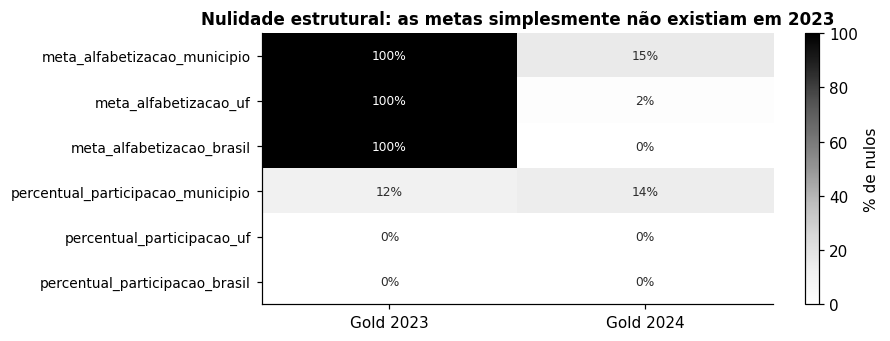

In [10]:
nulos_gold = eda.medir_nulos_por_ano({"Gold 2023": gold_2023, "Gold 2024": gold_2024})
display(nulos_gold[nulos_gold[["Gold 2023", "Gold 2024"]].max(axis=1) > 0].round(4))

nulos_micro = eda.medir_nulos_por_ano({"microdado 2023": aluno_2023, "microdado 2024": aluno_2024})
display(nulos_micro[nulos_micro[["microdado 2023", "microdado 2024"]].max(axis=1) > 0].round(4))

fig = eda.plotar_mapa_nulos(
    nulos_gold[nulos_gold[["Gold 2023", "Gold 2024"]].max(axis=1) > 0],
    "Nulidade estrutural: as metas simplesmente não existiam em 2023",
)
print(eda.salvar_figura(fig, "06_mapa_nulos_por_ano"))

In [11]:
# O nulo é informativo? Compara a taxa do alvo entre quem tem e quem não tem meta municipal.
sem_meta = gold_2024["meta_alfabetizacao_municipio"].isna()
print("municípios de 2024 sem meta municipal:", gold_2024.loc[sem_meta, "id_municipio"].nunique())
print("taxa de alfabetização com meta :", round(gold_2024.loc[~sem_meta, "alfabetizado"].mean(), 4))
print("taxa de alfabetização sem meta :", round(gold_2024.loc[sem_meta, "alfabetizado"].mean(), 4))
print("proficiência nula = ausente na prova:", round(float((aluno_2024['proficiencia'].isna() == (aluno_2024['presenca'] == 0)).mean()), 4))

municípios de 2024 sem meta municipal: 1207
taxa de alfabetização com meta : 0.5969
taxa de alfabetização sem meta : 0.6013
proficiência nula = ausente na prova: 0.9996


**Achado 7.** A nulidade é estrutural e determinística por ano, não aleatória. As colunas `meta_alfabetizacao_municipio`, `meta_alfabetizacao_uf` e `meta_alfabetizacao_brasil` são **100% nulas em 2023** e caem para 15,3%, 1,7% e 0,0013% em 2024. As metas do INEP começam em 2024; não faltou dado, a variável não existia. O plano registrava 53,2% e 45,8% porque media a base empilhada. Separado por ano, o padrão fica evidente.

Os 15,3% de 2024 são 1.207 municípios sem meta publicada. Entre eles a taxa de alfabetização é 60,13%, contra 59,69% de quem tem meta, uma diferença de 0,4pp. O indicador de nulidade dessa coluna quase não carrega sinal próprio. Não é motivo para removê-lo, e sim para não esperar nada dele.

No microdado, `proficiencia` e `peso_aluno` são nulas em 14,0% das linhas de 2023 e 12,7% das de 2024, e a nulidade coincide com `presenca = 0` em 99,96% dos casos. O resto são os 936 do achado 6.

A imputação será `SimpleImputer(strategy="median", add_indicator=True)` nas numéricas com nulo e `fill_value="AUSENTE"` nas categóricas. Como o modelo treina só em 2024, as colunas 100% nulas em 2023 não o afetam, mas afetariam qualquer tentativa de treinar em 2023, o que reforça a decisão de não fazer validação temporal ingênua.

---
## 7. Quantos alunos há por escola e por município

**Pergunta:** as taxas agregadas de escola são estimadas sobre quantos alunos?
**Decisão:** justificar, ou não, a suavização empírico-bayesiana prevista para a engenharia de features.

chave,id_escola,id_municipio
n_unidades,36525.000000,4871.000000
media,41.151485,308.572778
p1,8.000000,14.000000
p5,10.000000,24.000000
p10,12.000000,32.000000
p25,18.000000,55.000000
p50,32.000000,114.000000
p75,54.000000,251.000000
p90,82.000000,559.000000
p95,103.000000,1040.000000


images/eda/07_porte_escola_municipio.png


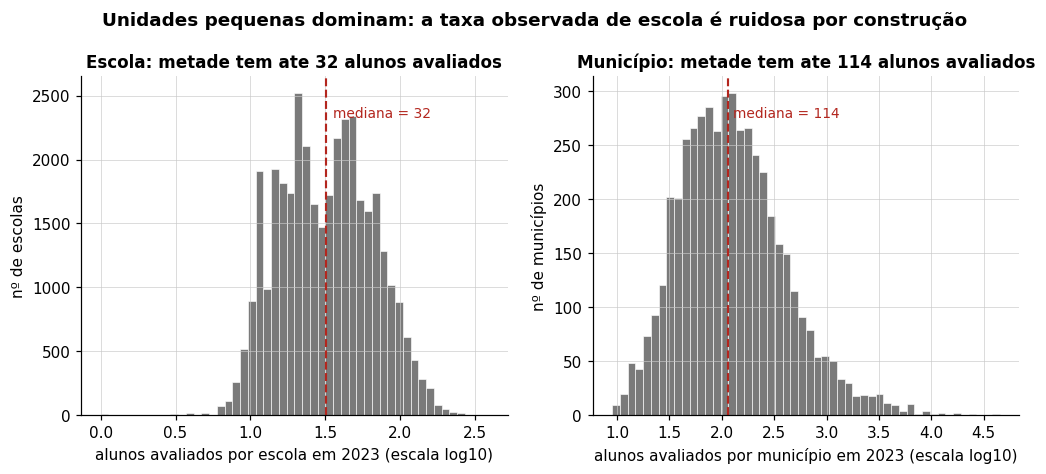

In [12]:
porte_escola = eda.medir_porte(presentes_2023, "id_escola")
porte_municipio = eda.medir_porte(presentes_2023, "id_municipio")
display(pd.concat([porte_escola, porte_municipio]).set_index("chave").T)

contagem_escola = presentes_2023.groupby("id_escola").size()
contagem_municipio = presentes_2023.groupby("id_municipio").size()
fig = eda.plotar_porte(contagem_escola, contagem_municipio)
print(eda.salvar_figura(fig, "07_porte_escola_municipio"))

**Achado 8.** A escola mediana de 2023 avaliou **32 alunos**, com p25 de 18 e p75 de 54; 10% das escolas avaliaram 12 ou menos, e só 10% passaram de 82. Uma taxa estimada sobre 32 alunos carrega erro-padrão de **8,8pp**, quase um quinto da amplitude total entre UFs. O município mediano avaliou 114 alunos, com erro-padrão de 4,7pp e p25 de 55.

A suavização empírico-bayesiana continua no plano por causa disso. Mas os itens 8 e 16 mostram que o problema da escola não é só ruído amostral, e é lá que essa decisão de fato se fecha.

---
## 8. A taxa de 2023 prediz a de 2024?

**Pergunta:** existe persistência temporal que justifique um modelo baseado em lag?
**Decisão:** a existência do projeto depende disso. Se a taxa de 2023 não predisser a de 2024, não há features.

,chave,porte_minimo,n_unidades,corr_pearson,ic_low,ic_high,corr_spearman
0,id_municipio,0,4841,0.6446,0.6241,0.6644,0.6328
1,id_municipio,20,4621,0.6718,0.6527,0.6883,0.6584
2,id_municipio,50,3592,0.7396,0.7217,0.7574,0.7242
3,id_municipio,200,1405,0.8093,0.7839,0.8301,0.7803


,chave,porte_minimo,n_unidades,corr_pearson,ic_low,ic_high,corr_spearman
0,id_escola,0,36051,0.2579,0.2483,0.2677,0.2532
1,id_escola,20,18764,0.2492,0.2355,0.2625,0.2389
2,id_escola,50,3492,0.2159,0.1825,0.2483,0.2091
3,id_escola,80,565,0.1829,0.1002,0.2574,0.1832


images/eda/08_persistencia_municipio.png


images/eda/08_persistencia_escola.png


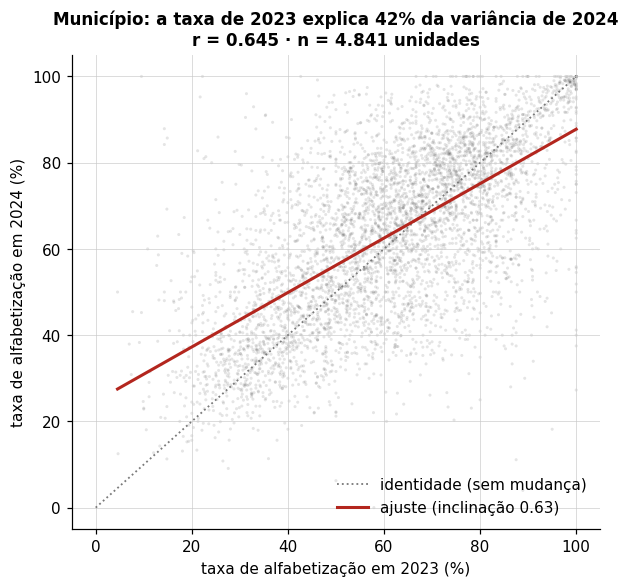

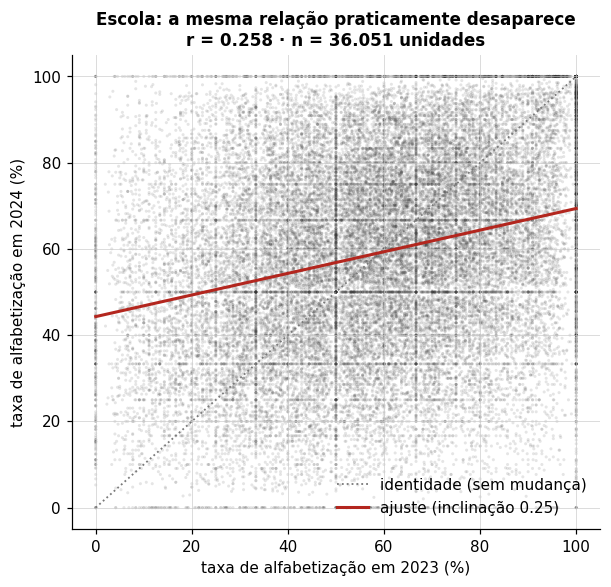

In [13]:
escola_2023 = eda.agregar_taxa(presentes_2023, "id_escola")
escola_2024 = eda.agregar_taxa(presentes_2024, "id_escola")
municipio_2023 = eda.agregar_taxa(presentes_2023, "id_municipio")
municipio_2024 = eda.agregar_taxa(presentes_2024, "id_municipio")

persistencia_municipio = eda.medir_persistencia(municipio_2023, municipio_2024, "id_municipio", (0, 20, 50, 200))
persistencia_escola = eda.medir_persistencia(escola_2023, escola_2024, "id_escola", (0, 20, 50, 80))
display(persistencia_municipio.round(4))
display(persistencia_escola.round(4))

fig = eda.plotar_persistencia(municipio_2023, municipio_2024, "id_municipio", "Município: a taxa de 2023 explica 42% da variância de 2024")
print(eda.salvar_figura(fig, "08_persistencia_municipio"))

fig = eda.plotar_persistencia(escola_2023, escola_2024, "id_escola", "Escola: a mesma relação praticamente desaparece")
print(eda.salvar_figura(fig, "08_persistencia_escola"))

**Achado 9.** No grão município, `corr(taxa 2023, taxa 2024) = 0,645`, com IC 95% de [0,624; 0,664] e Spearman de 0,633, sobre 4.841 municípios presentes nos dois anos. Isso é R² de aproximadamente 0,42: a taxa do ano anterior explica 42% da variância do ano seguinte.

No grão escola a mesma correlação despenca para **0,258**, com IC de [0,248; 0,268], e a inclinação do ajuste é 0,25 contra 0,63 do município. Reversão à média forte.

O lag municipal é, portanto, a espinha dorsal do modelo. O lag escolar entra, mas com expectativa baixa, e o item 16 explica por quê.

---
## 9. Correlação e VIF entre as features derivadas

Para medir correlação entre features é preciso antes construí-las. O protótipo abaixo, `eda.montar_agregados_lag`, é a versão mínima do que a engenharia de features vai formalizar em `src/preprocessing/feature_store.py`: agregados de escola, município e UF calculados exclusivamente sobre 2023 e aplicados à coorte de 2024.

**Pergunta:** há redundância a ponto de prejudicar o baseline linear e a leitura de SHAP?

In [14]:
agregados = eda.montar_agregados_lag(aluno_2023, dim_municipio)
for nivel, quadro in agregados.items():
    print(f"{nivel:10s} {quadro.shape}")

colunas_coorte = ["id_aluno", "id_escola", "id_municipio", "sigla_uf", "nome_regiao", "rede", "caderno", "alfabetizado"]
coorte = eda.montar_coorte_com_lag(gold_2024[colunas_coorte], agregados)
coorte["esc_taxa_alfab_lag1_suav"] = eda.suavizar_taxa_escola(coorte, k=30.0)

features_lag = sorted({c for c in coorte.columns if c.startswith(("esc_", "mun_", "uf_"))})
print(f"\n{len(features_lag)} features de lag sobre {len(coorte):,} alunos de 2024".replace(",", "."))

escola     (36525, 11)
municipio  (4871, 13)
uf         (23, 11)



35 features de lag sobre 1.852.788 alunos de 2024


pares com |Spearman| >= 0,95 — redundância a podar:


,feature_a,feature_b,correlacao
0,mun_n_alunos_lag1,mun_n_avaliados_lag1,0.9988
1,uf_n_alunos_lag1,uf_n_avaliados_lag1,0.9897
2,uf_prof_p25_lag1,uf_taxa_alfab_lag1,0.9870
3,esc_n_alunos_lag1,esc_n_avaliados_lag1,0.9841
4,mun_prof_media_lag1,mun_prof_p50_lag1,0.9785
5,mun_n_avaliados_lag1,mun_n_escolas_lag1,0.9751
6,mun_n_alunos_lag1,mun_n_escolas_lag1,0.9740
7,mun_prof_p50_lag1,mun_taxa_alfab_lag1,0.9737
8,mun_prof_p25_lag1,mun_taxa_alfab_lag1,0.9665
9,mun_prof_media_lag1,mun_taxa_alfab_lag1,0.9658


images/eda/09_correlacao_features_lag.png


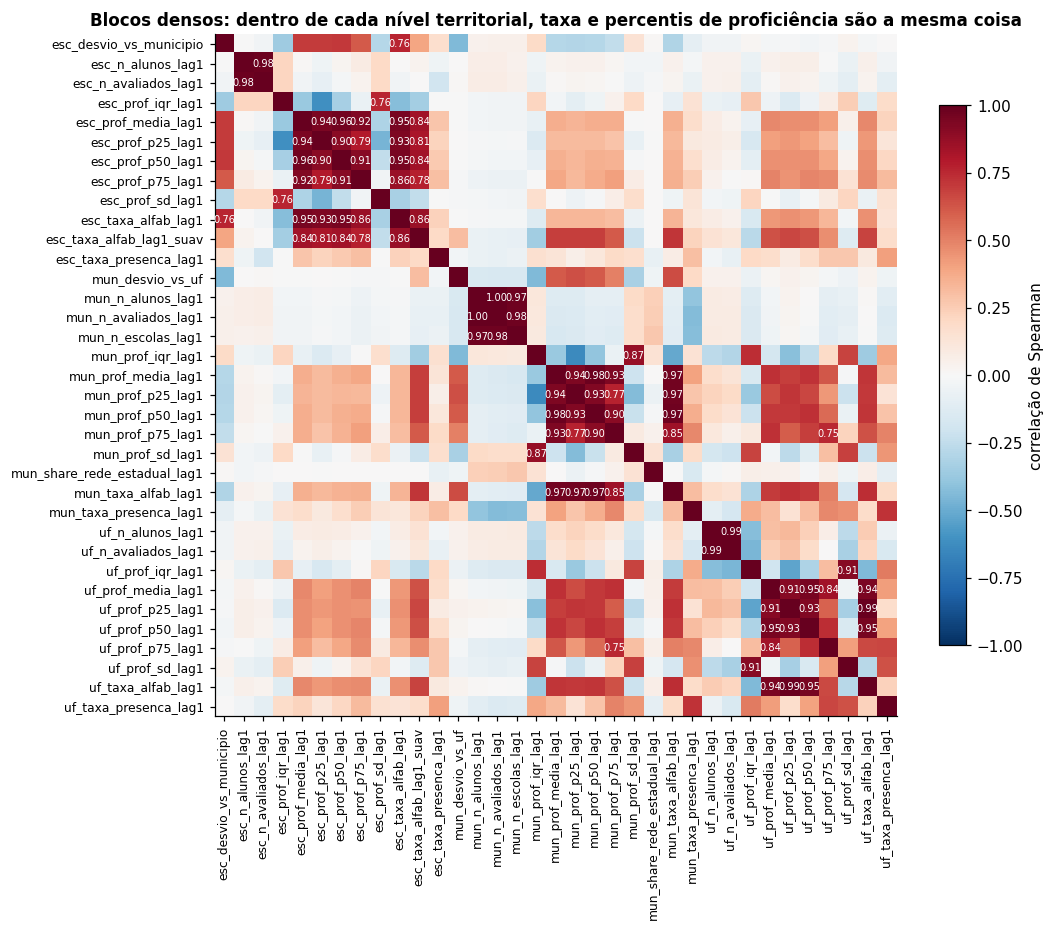

In [15]:
amostra = coorte[features_lag + ["alfabetizado"]].sample(300_000, random_state=config.RANDOM_STATE)
correlacao = amostra[features_lag].corr(method="spearman")

print("pares com |Spearman| >= 0,95 — redundância a podar:")
display(eda.sugerir_poda_por_correlacao(correlacao, 0.95).round(4))

fig = eda.plotar_heatmap_correlacao(correlacao, "Blocos densos: dentro de cada nível territorial, taxa e percentis de proficiência são a mesma coisa")
print(eda.salvar_figura(fig, "09_correlacao_features_lag"))

In [16]:
# Checagem anti-vazamento: nenhuma feature pode ter correlação alta com o alvo.
correlacao_com_alvo = amostra[features_lag].corrwith(amostra["alfabetizado"], method="spearman")
print("maior |correlação| com o alvo:", round(float(correlacao_com_alvo.abs().max()), 4),
      "->", correlacao_com_alvo.abs().idxmax())
print("limite da checklist de verificação final: 0,95\n")

# VIF sobre um conjunto sem dependências lineares exatas (sem IQR e sem desvios).
conjunto_sem_redundancia_exata = [
    "mun_taxa_alfab_lag1", "mun_prof_media_lag1", "mun_prof_sd_lag1", "mun_taxa_presenca_lag1",
    "mun_n_alunos_lag1", "mun_share_rede_estadual_lag1",
    "esc_taxa_alfab_lag1", "esc_prof_sd_lag1", "esc_taxa_presenca_lag1", "esc_n_alunos_lag1",
    "uf_taxa_alfab_lag1", "uf_prof_media_lag1",
]
display(eda.medir_vif(amostra[conjunto_sem_redundancia_exata]).round(2))

# E o mesmo conjunto sem a duplicata conceitual `*_prof_media` — a taxa já é a fração da
# distribuição de proficiência acima de 743, então as duas dizem a mesma coisa.
conjunto_podado = [c for c in conjunto_sem_redundancia_exata if not c.endswith("prof_media_lag1")]
display(eda.medir_vif(amostra[conjunto_podado]).round(2))

maior |correlação| com o alvo: 0.2722 -> mun_prof_media_lag1
limite da checklist de verificação final: 0,95



,feature,vif
0,uf_prof_media_lag1,30.34
1,uf_taxa_alfab_lag1,25.63
2,mun_prof_media_lag1,24.26
3,mun_taxa_alfab_lag1,21.23
4,mun_prof_sd_lag1,1.84
5,esc_taxa_alfab_lag1,1.52
6,mun_taxa_presenca_lag1,1.51
7,esc_prof_sd_lag1,1.23
8,esc_taxa_presenca_lag1,1.16
9,mun_n_alunos_lag1,1.12


,feature,vif
0,mun_taxa_alfab_lag1,2.88
1,uf_taxa_alfab_lag1,2.67
2,esc_taxa_alfab_lag1,1.52
3,mun_taxa_presenca_lag1,1.42
4,mun_prof_sd_lag1,1.35
5,esc_prof_sd_lag1,1.22
6,esc_taxa_presenca_lag1,1.14
7,mun_n_alunos_lag1,1.11
8,esc_n_alunos_lag1,1.06
9,mun_share_rede_estadual_lag1,1.05


**Achado 10.** Treze pares de features têm |Spearman| maior ou igual a 0,95, todos dentro do mesmo nível territorial: `mun_n_alunos` com `mun_n_avaliados` em 0,999, `mun_prof_media` com `mun_prof_p50` em 0,979, `mun_prof_p50` com `mun_taxa_alfab` em 0,974, `esc_prof_media` com `esc_taxa_alfab` em 0,952. Faz sentido. A taxa **é** a fração da distribuição de proficiência acima de 743, então taxa e percentis são reparametrizações da mesma curva.

**Achado 11, colinearidade perfeita e não apenas alta.** O VIF calculado sobre o conjunto completo devolve valores da ordem de 10¹³, alguns negativos: a matriz é singular. A causa é construtiva. `mun_prof_iqr` é `p75 - p25`, `esc_desvio_vs_municipio` é `esc_taxa - mun_taxa` e `mun_desvio_vs_uf` é `mun_taxa - uf_taxa`, todas combinações lineares exatas das outras colunas. Num conjunto sem essas dependências o VIF cai para a faixa de 1,1 a 30,3, e os quatro maiores valores são exatamente os pares `taxa_alfab` com `prof_media` do mesmo território: 30,3 e 25,6 na UF, 24,3 e 21,2 no município. Removendo as `*_prof_media`, nenhum VIF passa de **2,9**.

**Achado 12, nenhuma feature vaza.** A maior correlação de Spearman com o alvo entre as 35 features de lag é **0,272**, de `mun_prof_media_lag1`. A checklist de verificação final exige menos de 0,95, e estamos a uma ordem de grandeza de distância. É o esperado quando todas as features vêm de um ano anterior ao alvo.

Para a engenharia de features isso se traduz em dois caminhos separados. O baseline linear recebe o subconjunto podado medido acima, com uma métrica de nível por território (`taxa_alfab` ou `prof_media`, nunca as duas) e uma de dispersão, jamais `p25`, `p75` e `iqr` ao mesmo tempo, o que mantém todo VIF abaixo de 3. O LightGBM pode receber o conjunto completo, já que árvore não sofre com colinearidade, mas a leitura de SHAP terá de agrupar as features correlacionadas por família. Sem isso a importância se dilui entre colunas que dizem a mesma coisa.

---
## 10. `proficiencia` contra `alfabetizado`, o vazamento número um (A1)

**Pergunta:** qual a relação exata entre proficiência e o alvo?
**Decisão:** confirmar por evidência a exclusão da `proficiencia` do ano corrente.

> A `proficiencia` aparece aqui como objeto de análise. Ela não é, e não será, preditora de 2024. No modelo ela só entra agregada por escola, município ou UF a partir de 2023.

,n,max_proficiencia_classe_0,min_proficiencia_classe_1,limiar_declarado,ha_sobreposicao,corr_pearson_com_alvo,auc_univariada
2023,1502809,742.999817,743.0,743.0,False,0.791643,1.0
2024,1851852,742.999634,743.0,743.0,False,0.798897,1.0


images/eda/10_corte_deterministico_proficiencia.png


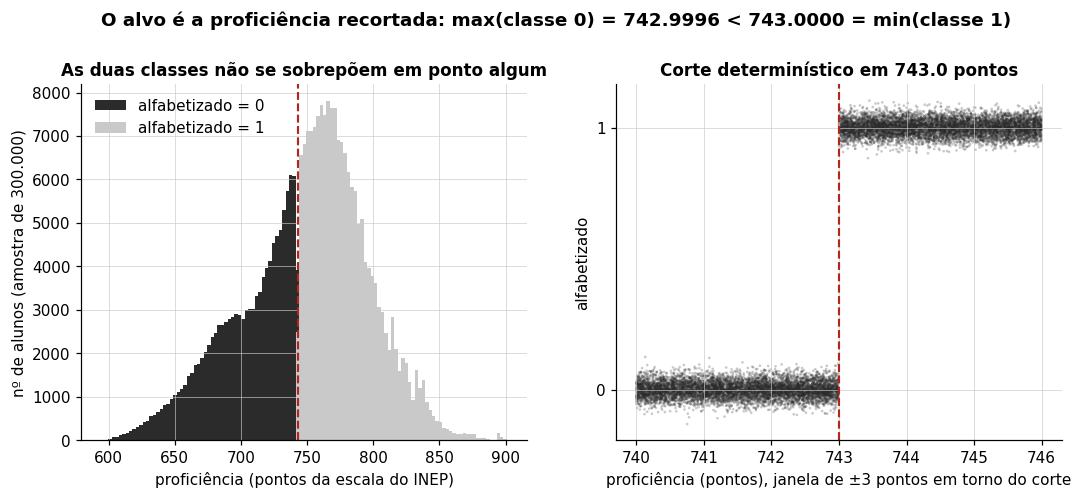

In [17]:
corte_2024 = eda.medir_corte_proficiencia(presentes_2024)
corte_2023 = eda.medir_corte_proficiencia(presentes_2023)
display(pd.DataFrame([corte_2023, corte_2024], index=[2023, 2024]))

fig = eda.plotar_corte_proficiencia(presentes_2024, corte_2024)
print(eda.salvar_figura(fig, "10_corte_deterministico_proficiencia"))

**Achado 13, que confirma A1.** Em 2024, `max(proficiencia | alfabetizado = 0)` é 742,9996 e `min(proficiencia | alfabetizado = 1)` é 743,0000. Zero sobreposição, **AUC de 1,000 exata**. Em 2023 o quadro se repete: 742,9998 contra 743,0000.

O `alfabetizado` não é "fortemente correlacionado" com a proficiência. A correlação de Pearson de 0,799 é apenas o artefato de binarizar uma contínua. Ele **é** `1[proficiencia >= 743]`. Uma feature dessas num modelo daria AUC 1,0, e o projeto inteiro seria um bug.

Três consequências. A `proficiencia` e o `peso_aluno` do ano corrente permanecem em `config.COLS_PROIBIDAS`, e já há teste verificando que a Gold não os expõe. A proficiência de 2023, pelo mesmo motivo, é a melhor matéria-prima de features que existe na base, e é dela que saem `*_prof_media_lag1` e os percentis. E o README precisa declarar que o alvo é um corte binário em 743 pontos, o que joga fora a gradação: um aluno com 742,9 e um com 400 caem na mesma classe.

---
## 11. Taxa observada em 2024 contra a meta de 2024

**Pergunta:** quantos municípios ficaram abaixo da meta, e quanto falta?
**Decisão:** dimensiona a camada estratégica municipal, no gap de esforço.

municípios comparáveis: 5352 | com meta de 2024 publicada: 5232
não atingiram a meta de 2024: 45.7%


,gap_pp,gap_ate_meta_2025_pp
count,5232.00,5352.00
mean,1.45,1.84
std,14.94,14.50
min,-68.89,-76.28
25%,-7.28,-7.90
50%,1.40,1.90
75%,10.95,11.13
max,84.27,68.89


já superam a meta de 2025: 44.5%
images/eda/11_taxa_observada_vs_meta_2024.png


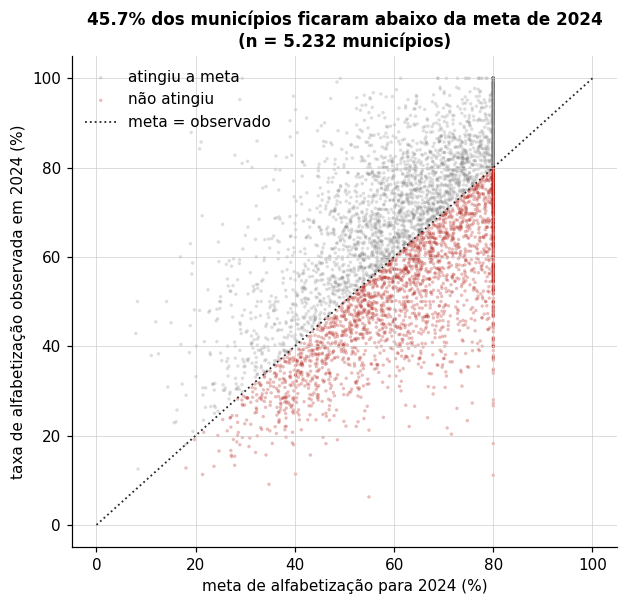

In [18]:
metas = loader.carregar_meta_municipio()
metas_2024 = metas[metas["ano"] == 2024][
    ["id_municipio", "taxa_alfabetizacao", "meta_alfabetizacao_2024", "meta_alfabetizacao_2025", "nivel_alfabetizacao"]
]
taxa_observada = municipio_2024.assign(taxa_2024_pct=lambda d: d["taxa"] * 100)[["id_municipio", "taxa_2024_pct", "n"]]

gap = eda.medir_gap_meta(metas_2024, taxa_observada)
gap["gap_ate_meta_2025_pp"] = gap["meta_alfabetizacao_2025"] - gap["taxa_2024_pct"]
com_meta_2024 = gap.dropna(subset=["gap_pp"])   # 120 municípios não têm meta de 2024 publicada
print("municípios comparáveis:", len(gap), "| com meta de 2024 publicada:", len(com_meta_2024))
print("não atingiram a meta de 2024:", f"{(~com_meta_2024['atingiu_meta']).mean():.1%}")
display(gap[["gap_pp", "gap_ate_meta_2025_pp"]].describe().round(2))
print("já superam a meta de 2025:", f"{(gap['gap_ate_meta_2025_pp'] <= 0).mean():.1%}")

fig = eda.plotar_taxa_versus_meta(gap.dropna(subset=["meta_alfabetizacao_2024"]))
print(eda.salvar_figura(fig, "11_taxa_observada_vs_meta_2024"))

In [19]:
# Volatilidade da evolução municipal — o denominador da discussão de metas.
evolucao = municipio_2023.merge(municipio_2024, on="id_municipio", suffixes=("_23", "_24"))
evolucao["delta_pp"] = (evolucao["taxa_24"] - evolucao["taxa_23"]) * 100
print("evolução 2023 -> 2024, em pontos percentuais:")
print(evolucao["delta_pp"].describe().round(2).to_string())
print("municípios que pioraram:", f"{(evolucao['delta_pp'] < 0).mean():.1%}")
print()
for rotulo, recorte in [
    ("< 50 alunos", evolucao[(evolucao["n_23"] < 50) & (evolucao["n_24"] < 50)]),
    ("50–200 alunos", evolucao[(evolucao["n_23"].between(50, 199)) & (evolucao["n_24"].between(50, 199))]),
    (">= 200 alunos", evolucao[(evolucao["n_23"] >= 200) & (evolucao["n_24"] >= 200)]),
]:
    print(f"  {rotulo:14s} n = {len(recorte):5d} | desvio-padrão do delta = {recorte['delta_pp'].std():.1f}pp")

evolução 2023 -> 2024, em pontos percentuais:
count    4841.00
mean        2.19
std        16.63
min       -84.89
25%        -6.47
50%         2.11
75%        11.81
max        90.48
municípios que pioraram: 42.9%

  < 50 alunos    n =   907 | desvio-padrão do delta = 23.9pp
  50–200 alunos  n =  2010 | desvio-padrão do delta = 15.5pp
  >= 200 alunos  n =  1405 | desvio-padrão do delta = 11.0pp


**Achado 14.** Dos 5.232 municípios com meta de 2024 publicada, **45,7%** ficaram abaixo dela. Dos 5.352 com metas, 120 não têm meta para 2024. O gap mediano é de 1,4pp, ou seja, quem passou passou por pouco e quem não passou também ficou perto, com desvio-padrão de 14,9pp. Para a meta de 2025, o esforço mediano necessário é de **1,9pp**, e **44,5% dos municípios já a superam** com a taxa de 2024.

**Achado 15, a volatilidade é maior que o alvo da política.** A evolução mediana de 2023 para 2024 foi de 2,1pp, com desvio-padrão de **16,6pp**, mínimo de -84,9pp e máximo de +90,5pp, e **42,9% dos municípios pioraram**. O desvio depende inteiramente do porte: 23,9pp em municípios com menos de 50 alunos avaliados, contra 11,0pp naqueles com 200 ou mais.

Traduzindo para linguagem de gestão: exigir 1,9pp de avanço de um município que oscila 24pp por ruído amostral é medir sorte, não política.

Isso sustenta as três entregas da camada estratégica municipal, que são o gap de esforço aritmético, confiável por não depender de modelo, a projeção com incerteza expressa como `P(taxa 2025 < meta 2025)`, e a recomendação de que municípios com menos de cerca de 50 alunos avaliados não tenham meta avaliada individualmente sem intervalo de confiança.

---
## 12. Cobertura do lag

**Pergunta:** quantos alunos de 2024 têm histórico de 2023, e quem não tem é diferente?
**Decisão:** as flags `tem_historico_escola` e `tem_historico_municipio`, e a estratégia de imputação.

,chave,unidades_2024,unidades_2023,pct_unidades_com_historico,pct_alunos_com_historico,alunos_sem_historico
0,id_escola,42328,36525,0.8517,0.7898,389491
1,id_municipio,5517,4871,0.8775,0.7689,428157


,grupo,chave,n_alunos,taxa_alfabetizado,ic_low,ic_high
0,com histórico,id_escola,1463297,0.6003,0.5995,0.6011
1,sem histórico,id_escola,389491,0.5871,0.5856,0.5886
2,com histórico,id_municipio,1424631,0.6014,0.6006,0.6022
3,sem histórico,id_municipio,428157,0.5846,0.5831,0.5861


images/eda/12_cobertura_do_lag.png


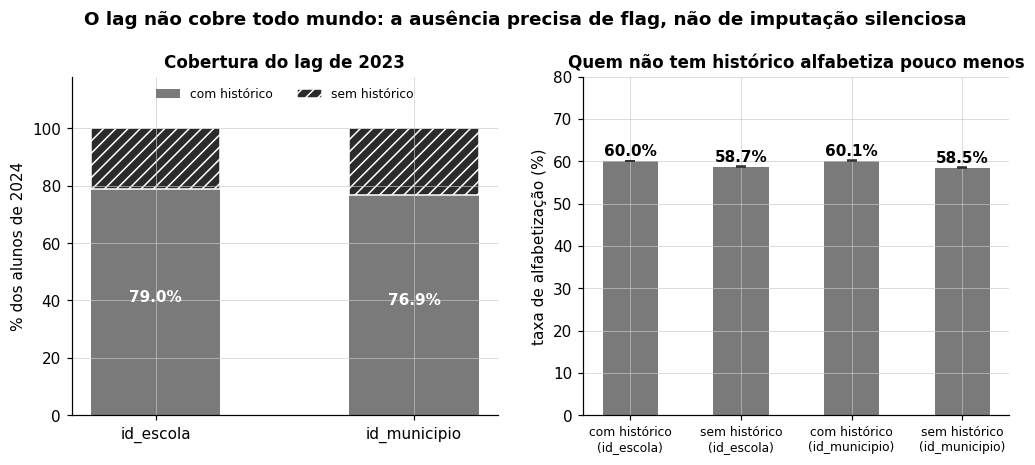

In [20]:
cobertura = eda.medir_cobertura_lag(gold_2024, presentes_2023)
display(cobertura.round(4))

perfis = pd.concat(
    [
        eda.medir_perfil_sem_historico(gold_2024, presentes_2023, "id_escola"),
        eda.medir_perfil_sem_historico(gold_2024, presentes_2023, "id_municipio"),
    ],
    ignore_index=True,
)
display(perfis.round(4))

fig = eda.plotar_cobertura_lag(cobertura, perfis)
print(eda.salvar_figura(fig, "12_cobertura_do_lag"))

**Achado 16.** Das escolas de 2024, 85,2% já existiam em 2023, cobrindo **79,0% dos alunos**. No grão município são 87,7% das unidades e **76,9% dos alunos**. Sobram 389.491 alunos sem lag de escola e 428.157 sem lag de município.

Quem não tem histórico alfabetiza um pouco menos: 58,71% contra 60,03% no caso da escola, 58,46% contra 60,14% no do município. A diferença fica entre 1,3pp e 1,7pp e os ICs são disjuntos, mas com 1,85 milhão de linhas quase tudo é significante. O que vale aqui é o tamanho, e o tamanho diz que o sinal é fraco.

As flags `tem_historico_*` ficam explícitas, e as features de lag são imputadas com `add_indicator=True`. Elas não vão liderar a importância, mas evitam que o modelo trate "sem histórico" como "histórico médio", que é exatamente o que uma imputação silenciosa faria.

---
## 13. `id_aluno` entre anos (A2), a armadilha mais cara do projeto

**Pergunta:** dá para acompanhar o mesmo aluno de 2023 para 2024?
**Decisão:** se desse, o projeto teria features individuais e um teto de performance muito mais alto. Não dá, e a prova disso precisa estar aqui.

,valor
ids_2023,1.747439e+06
ids_2024,2.120560e+06
ids_em_ambos_anos,1.515671e+06
pct_mesma_escola,1.215303e-03
pct_mesmo_municipio,1.591566e-01
pares_falsos_estimados,1.513829e+06


images/eda/13_reciclagem_id_aluno.png


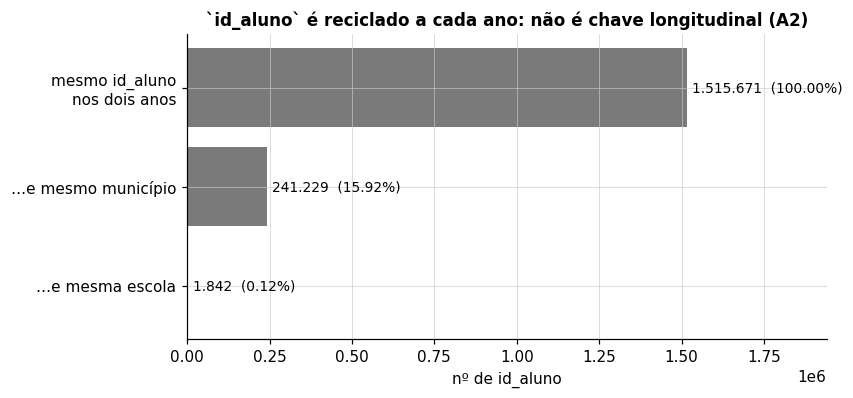

In [21]:
reciclagem = eda.medir_reciclagem_id_aluno(aluno_2023, aluno_2024)
display(pd.Series(reciclagem).to_frame("valor"))

fig = eda.plotar_reciclagem_id_aluno(reciclagem)
print(eda.salvar_figura(fig, "13_reciclagem_id_aluno"))

**Achado 17, que confirma A2.** Há **1.515.671** valores de `id_aluno` presentes nos dois anos. Desses, apenas **0,12% estão na mesma escola** e 15,9% no mesmo município, praticamente a taxa que se espera do acaso dado o tamanho relativo dos municípios. O ID é sequencial e reciclado a cada edição. Não é matrícula.

Um `merge` por `id_aluno` entre 2023 e 2024 produziria cerca de 1,51 milhão de pares falsos e um conjunto de features "individuais" inteiramente fabricado. O agravante é que ele funcionaria: como o prefixo do ID codifica a UF, mostrado no item 14, o par falso ainda carregaria sinal territorial e a métrica subiria. É o pior tipo de bug, o que se disfarça de resultado.

O join por `id_aluno` entre anos fica proibido, travado em `tests/test_dados.py::test_id_aluno_nao_e_chave_longitudinal`. A consequência é assumida: não há acompanhamento de coorte, e portanto nenhuma feature individual. É a razão de fundo do teto de AUC em torno de 0,65.

---
## 14. O prefixo de `id_aluno` codifica a UF (A3)

**Pergunta:** `id_aluno` é inofensivo se entrar como numérica?

{'n_amostra': 300000, 'pct_prefixo_igual_ao_codigo_uf': 1.0, 'n_prefixos': 26, 'prefixos_com_uma_unica_uf': 26}


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25
prefixo,11,12,13,15,16,17,21,22,23,24,25,26,27,28,29,31,32,33,35,41,42,43,50,51,52,53
n_ufs,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
uf_dominante,RO,AC,AM,PA,AP,TO,MA,PI,CE,RN,PB,PE,AL,SE,BA,MG,ES,RJ,SP,PR,SC,RS,MS,MT,GO,DF


images/eda/14_prefixo_id_aluno_por_uf.png


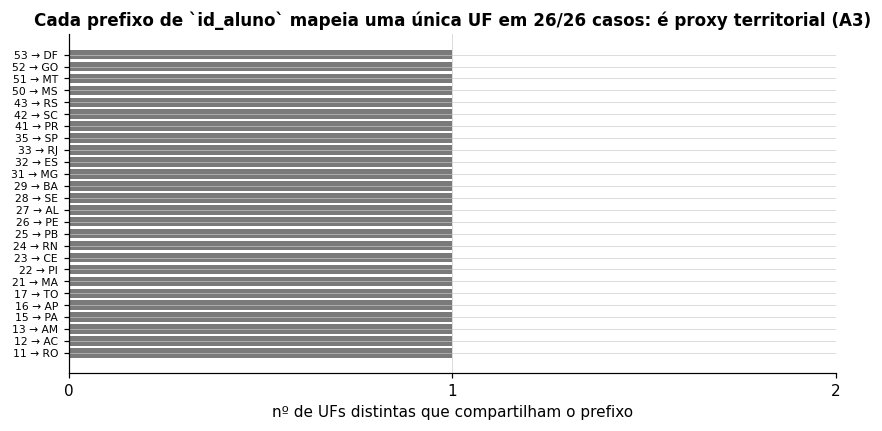

In [22]:
prefixo = eda.medir_prefixo_id_aluno(aluno_2024, dim_municipio)
print({k: v for k, v in prefixo.items() if k != "tabela_prefixo_uf"})
display(prefixo["tabela_prefixo_uf"].T)

fig = eda.plotar_prefixo_id_aluno(prefixo)
print(eda.salvar_figura(fig, "14_prefixo_id_aluno_por_uf"))

**Achado 18, que confirma A3.** Em 300 mil alunos amostrados, os dois primeiros dígitos de `id_aluno` reproduzem o código de UF do IBGE em **100,0%** dos casos, e cada um dos 26 prefixos mapeia uma única UF.

Como numérica, `id_aluno` seria um proxy territorial de alta resolução entrando pela porta dos fundos. Pior: atravessaria até o `GroupShuffleSplit` por município, porque o prefixo identifica a UF, que é compartilhada entre os municípios de treino e de teste.

Por isso `id_aluno` permanece em `config.COLS_PROIBIDAS`, descartada e não apenas ignorada.

---
## 15. As metas são determinísticas (A4)

**Pergunta:** a meta municipal é uma variável independente ou uma função da própria taxa observada?
**Decisão:** se for função, ela é um lag disfarçado, legítima como feature e ilegítima como alvo preditivo. É isso que reformula a pergunta de negócio 4.

,meta,n_valores_distintos,pct_nulo,media,desvio_padrao,corr_com_taxa_base
0,meta_alfabetizacao_2024,2745,0.0224,62.1517,15.0982,0.9790
1,meta_alfabetizacao_2025,2501,0.0000,65.2454,12.6326,0.9765
2,meta_alfabetizacao_2026,2284,0.0000,68.5578,9.8560,0.9745
3,meta_alfabetizacao_2027,1889,0.0000,71.7720,7.0608,0.9741
4,meta_alfabetizacao_2028,1387,0.0000,74.7949,4.4008,0.9757
5,meta_alfabetizacao_2029,755,0.0000,77.5522,2.0184,0.9791
6,meta_alfabetizacao_2030,1,0.0000,80.0000,0.0000,NaN


fração de municípios em que a meta é idêntica nas linhas de 2023 e de 2024:
meta_alfabetizacao_2024    1.0
meta_alfabetizacao_2025    1.0
meta_alfabetizacao_2026    1.0
meta_alfabetizacao_2027    1.0
meta_alfabetizacao_2028    1.0
meta_alfabetizacao_2029    1.0
meta_alfabetizacao_2030    1.0


C:\Users\Vyctor\Documents\pos-tech\fase-3\Fase3_TechChallenge-Predicao-Inteligencia-Analitica-para-Alfabetizacao-no-Brasil\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\Vyctor\Documents\pos-tech\fase-3\Fase3_TechChallenge-Predicao-Inteligencia-Analitica-para-Alfabetizacao-no-Brasil\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


images/eda/15_meta_versus_taxa_base.png


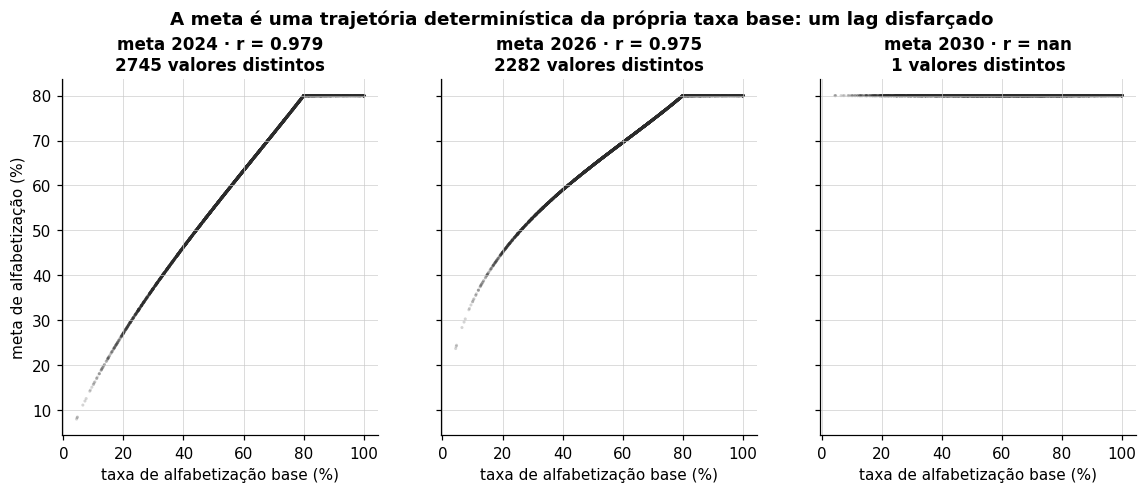

In [23]:
determinismo = eda.medir_determinismo_das_metas(metas[metas["ano"] == 2023])
display(determinismo.round(4))

metas_2023 = metas[metas["ano"] == 2023].set_index("id_municipio")
metas_2024_idx = metas[metas["ano"] == 2024].set_index("id_municipio")
comuns = metas_2023.index.intersection(metas_2024_idx.index)
colunas_meta = [c for c in metas.columns if c.startswith("meta_alfabetizacao_")]
identicas = {
    c: float((metas_2023.loc[comuns, c].fillna(-1) == metas_2024_idx.loc[comuns, c].fillna(-1)).mean())
    for c in colunas_meta
}
print("fração de municípios em que a meta é idêntica nas linhas de 2023 e de 2024:")
print(pd.Series(identicas).to_string())

fig = eda.plotar_meta_versus_taxa_base(
    metas[metas["ano"] == 2023], ("meta_alfabetizacao_2024", "meta_alfabetizacao_2026", "meta_alfabetizacao_2030")
)
print(eda.salvar_figura(fig, "15_meta_versus_taxa_base"))

**Achado 19, que confirma A4.** A `corr(meta 2025, taxa base)` é de 0,976 e a `corr(meta 2024, taxa base)` é de 0,979. A `meta_alfabetizacao_2030` tem **um único valor, 80, para os 5.352 municípios**, e a dispersão das metas cai monotonicamente conforme o ano avança: desvio-padrão de 15,1 em 2024, 2,0 em 2029 e 0 em 2030. As metas são 100% idênticas nas linhas de 2023 e de 2024, em todas as sete colunas.

A meta é, literalmente, uma interpolação da taxa base até 80 em 2030. Ela não contém informação nova sobre o município. Contém a taxa base, reescalada.

Três desdobramentos. A `meta_alfabetizacao_municipio` continua no modelo, porque não faz mal, mas sem expectativa de sinal independente e declarada no README como lag disfarçado. O `gap_meta` é quase constante por construção, então não serve como feature diferenciadora. E isso sustenta a reformulação da pergunta de negócio 4: com estes atributos, prever quem não vai bater a meta acrescenta pouco à taxa base do município, e a AUC de 0,485 do diagnóstico inicial é consequência da construção da meta, não de erro de implementação. É o limite dos métodos e dados aqui testados; não estabelece que o não atingimento seja imprevisível em geral.

---
## 16. O sinal é territorial, não escolar

**Pergunta:** a taxa da escola é fraca porque é ruidosa, já que são poucos alunos, ou porque a escola realmente não carrega informação além do território?
**Decisão:** se for ruído, a suavização empírico-bayesiana resolve e vira pilar da engenharia de features. Se for falta de informação, a suavização é cosmética e o esforço deve migrar para o grão municipal.

Três testes independentes, do mais fraco ao mais forte.

,feature,faixa_porte,n_alunos,n_escolas,auc
0,esc_taxa_alfab_lag1,0–20,385771,10197,0.5596
1,esc_taxa_alfab_lag1,20–50,615149,15466,0.5599
2,esc_taxa_alfab_lag1,50–80,283532,6467,0.5561
3,esc_taxa_alfab_lag1,≥ 80,178845,3921,0.5536


,feature,faixa_porte,n_alunos,n_escolas,auc
0,mun_taxa_alfab_lag1,0–20,374697,10016,0.6530
1,mun_taxa_alfab_lag1,20–50,589648,15085,0.6544
2,mun_taxa_alfab_lag1,50–80,265291,6194,0.6531
3,mun_taxa_alfab_lag1,≥ 80,164857,3718,0.6467


images/eda/16_auc_taxa_escola_por_porte.png


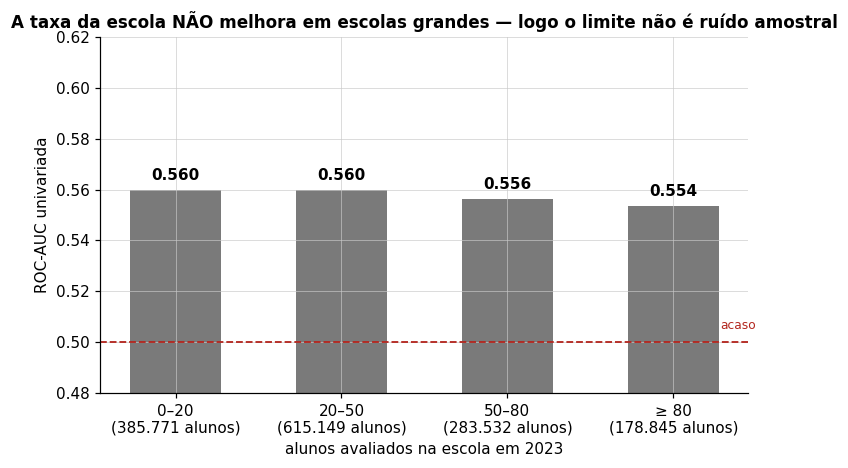

In [24]:
# Teste 1 — a AUC da taxa da escola melhora em escolas grandes?
auc_escola_por_porte = eda.medir_auc_por_porte_da_escola(coorte, "esc_taxa_alfab_lag1")
auc_municipio_por_porte = eda.medir_auc_por_porte_da_escola(coorte, "mun_taxa_alfab_lag1")
display(auc_escola_por_porte.round(4))
display(auc_municipio_por_porte.round(4))

fig = eda.plotar_auc_por_porte(auc_escola_por_porte, "A taxa da escola NÃO melhora em escolas grandes — logo o limite não é ruído amostral")
print(eda.salvar_figura(fig, "16_auc_taxa_escola_por_porte"))

,k,auc
0,0,0.5608
1,5,0.5768
2,10,0.5878
3,20,0.6039
4,30,0.6148
5,50,0.6281
6,100,0.6420
7,200,0.6494
8,500,0.6527


images/eda/16_grid_suavizacao_k.png


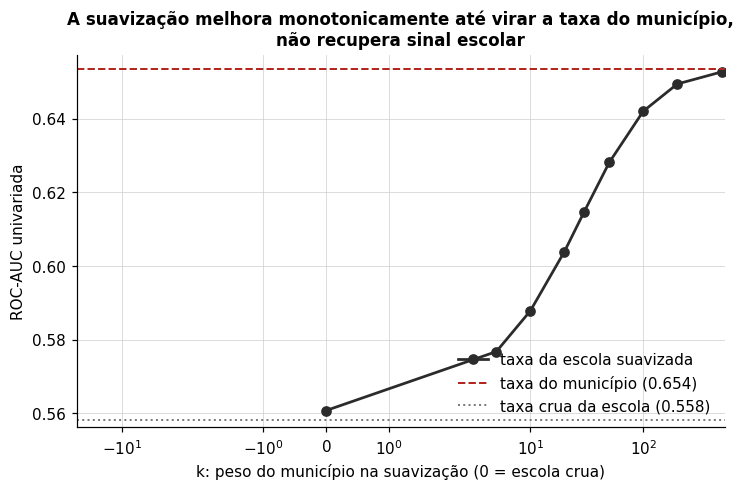

In [25]:
# Teste 2 — para onde converge a suavização empírico-bayesiana?
grid_k = eda.medir_grid_suavizacao(coorte)
display(grid_k.round(4))

auc_municipio = eda.auc_univariada(coorte["alfabetizado"].to_numpy(), coorte["mun_taxa_alfab_lag1"].to_numpy())
auc_escola = eda.auc_univariada(coorte["alfabetizado"].to_numpy(), coorte["esc_taxa_alfab_lag1"].to_numpy())
fig = eda.plotar_grid_suavizacao(grid_k, auc_municipio, auc_escola)
print(eda.salvar_figura(fig, "16_grid_suavizacao_k"))

,chave,porte_minimo,n_unidades,corr_pearson,ic_low,ic_high,corr_spearman
0,id_escola,0,36051,0.0094,-0.0014,0.0200,0.0053
1,id_escola,20,18764,-0.0050,-0.0186,0.0087,-0.0061
2,id_escola,50,3492,0.0052,-0.0280,0.0396,0.0089
3,id_escola,80,565,-0.0179,-0.1037,0.0639,0.0020


images/eda/16_persistencia_desvio_escolar.png


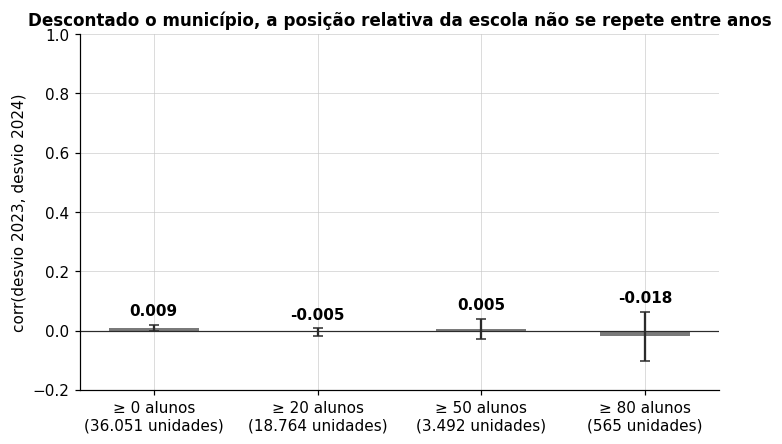

In [26]:
# Teste 3 — o desvio da escola em relação ao próprio município se repete entre anos?
desvio_2023 = eda.montar_desvio_escolar(aluno_2023)
desvio_2024 = eda.montar_desvio_escolar(aluno_2024)
persistencia_desvio = eda.medir_persistencia(desvio_2023, desvio_2024, "id_escola", (0, 20, 50, 80))
display(persistencia_desvio.round(4))

fig = eda.plotar_persistencia_por_porte(
    persistencia_desvio,
    "Descontado o município, a posição relativa da escola não se repete entre anos",
    rotulo_y="corr(desvio 2023, desvio 2024)",
    limite_inferior=-0.2,
)
print(eda.salvar_figura(fig, "16_persistencia_desvio_escolar"))

**Achado 20, e a hipótese do ruído amostral cai com três evidências.**

A primeira é que a AUC da taxa da escola não melhora com o porte: 0,560 em escolas de até 20 alunos, 0,560 entre 20 e 50, 0,556 entre 50 e 80 e 0,554 em escolas com 80 ou mais. Se o problema fosse erro amostral, a AUC subiria com o tamanho. Ela cai de leve. Em qualquer faixa de porte a taxa municipal entrega entre 0,647 e 0,654, sempre melhor.

A segunda é que a suavização converge para o município, não para uma escola "limpa". A AUC da taxa suavizada cresce monotonicamente com `k`: 0,561 em k=0, 0,614 em k=30, 0,642 em k=100 e 0,653 em k=500, sem nunca superar a taxa municipal pura de 0,654. O melhor `k` é o maior da grade, o que significa que a suavização funciona apagando a escola.

A terceira é que o desvio da escola em relação ao próprio município tem persistência zero. A `corr(desvio 2023, desvio 2024)` é de 0,009 no total, -0,005 em escolas com 20 ou mais alunos, 0,005 com 50 ou mais e -0,018 com 80 ou mais. Nenhum intervalo se afasta do zero.

Essa terceira evidência é a decisiva, porque não depende de tamanho de amostra. Em escolas com 80 ou mais alunos avaliados nos dois anos, onde a taxa é medida com precisão, a posição relativa da escola dentro do município não se repete no ano seguinte. Some-se a isso que 60,5% da variância da taxa escolar, considerando escolas com 20 ou mais alunos, é variância *entre* municípios.

Isso muda o plano em três pontos. A suavização empírico-bayesiana deixa de ser calibrada por CV como se houvesse um `k` ótimo interno a descobrir, porque a grade de 10 a 100 já está medida e é monotônica; ela entra com `k` fixo e documentado, como conveniência de imputação, na qual escola sem histórico herda o município, e não como recuperação de sinal. A `esc_desvio_vs_municipio` sai da lista de features, ou entra como segundo controle negativo ao lado do `caderno`: sua AUC univariada é 0,457, isto é, 0,543 invertida, não porque escolas relativamente boas alfabetizem menos, mas porque subtrair a taxa municipal inteira de uma taxa escolar ruidosa super-subtrai justamente o componente que prediz. Mantê-la seria convidar a interpretabilidade a contar uma história causal falsa. E o esforço de engenharia de features vai para o grão municipal, com percentis de proficiência, presença e porte, em vez do escolar.

---
## 17. Persistência municipal por faixa de porte

**Pergunta:** onde a predição realmente funciona?
**Decisão:** é o número que sustenta a camada estratégica municipal.

,chave,porte_minimo,n_unidades,corr_pearson,ic_low,ic_high,corr_spearman
0,id_municipio,0,4841,0.6446,0.6241,0.6644,0.6328
1,id_municipio,20,4621,0.6718,0.6527,0.6883,0.6584
2,id_municipio,50,3592,0.7396,0.7217,0.7574,0.7242
3,id_municipio,200,1405,0.8093,0.7839,0.8301,0.7803


images/eda/17_persistencia_municipal_por_porte.png


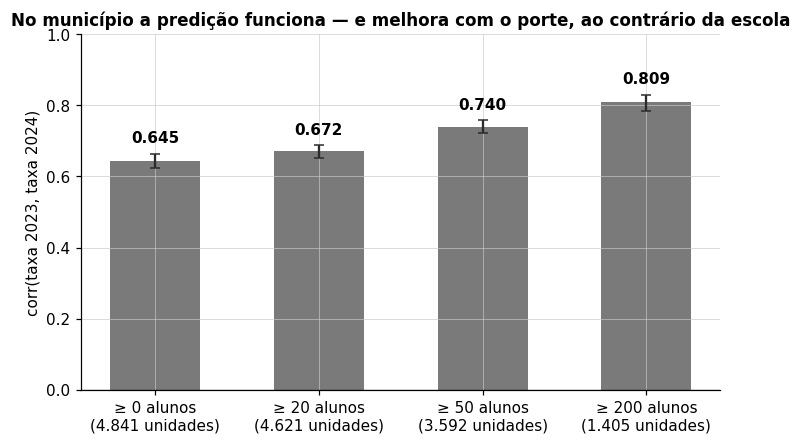

In [27]:
display(persistencia_municipio.round(4))

fig = eda.plotar_persistencia_por_porte(
    persistencia_municipio, "No município a predição funciona — e melhora com o porte, ao contrário da escola"
)
print(eda.salvar_figura(fig, "17_persistencia_municipal_por_porte"))

**Achado 21.** A `corr(taxa 2023, taxa 2024)` no grão município é de **0,645** considerando todos os municípios, **0,672** nos que têm 20 ou mais alunos, **0,740** nos com 50 ou mais e **0,809** nos com 200 ou mais, com ICs de bootstrap que não se sobrepõem entre os extremos. Nos municípios de 200 alunos ou mais, o R² chega a 0,65.

O contraste com o item 16 é o achado central desta EDA: a mesma métrica que é estável no município é ruído na escola, e ela melhora com o porte no município enquanto piora com o porte na escola.

Três consequências. A camada estratégica municipal tem base empírica sólida, e é onde está o valor da entrega. O ranking de risco municipal precisa de *shrinkage*, já que a persistência cai para 0,645 na base completa justamente por causa dos municípios pequenos. E o `GroupShuffleSplit` por município fica reforçado: se é o município que carrega o sinal, deixá-lo aparecer nos dois lados do split seria memorização, não generalização.

---
## 18. Viés de seleção dos ausentes

**Pergunta:** os 12,6% de alunos ausentes faltam ao acaso?
**Decisão:** se não faltam, toda taxa medida é otimista. Isso vira limitação a declarar, além de justificar `taxa_presenca` como feature.

taxa de presença 2023: 0.8601
taxa de presença 2024: 0.8737
ausentes em 2024: 267772
ausentes com alfabetizado = 1: 0


,quintil_presenca,n_municipios,n_alunos_presentes,k,taxa_presenca_media,taxa_alfabetizado,ic_low,ic_high
0,Q1,1063,551406,294527,0.7967,0.5341,0.5328,0.5355
1,Q2,1064,564345,333666,0.8820,0.5912,0.5900,0.5925
2,Q3,1062,342767,207716,0.9177,0.6060,0.6044,0.6076
3,Q4,1069,200432,126926,0.9482,0.6333,0.6311,0.6354
4,Q5,1057,190869,142313,0.9848,0.7456,0.7436,0.7476


images/eda/18_vies_ausencia_por_presenca.png


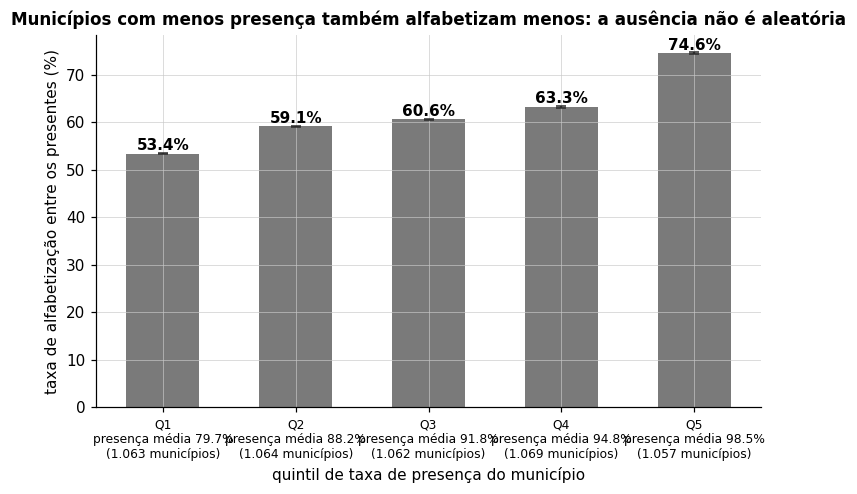

In [28]:
print("taxa de presença 2023:", round(float(aluno_2023["presenca"].mean()), 4))
print("taxa de presença 2024:", round(float(aluno_2024["presenca"].mean()), 4))
print("ausentes em 2024:", int((aluno_2024["presenca"] == 0).sum()))
print("ausentes com alfabetizado = 1:", int(aluno_2024.loc[aluno_2024["presenca"] == 0, "alfabetizado"].sum()))

vies = eda.medir_vies_de_ausencia(aluno_2024)
display(vies.round(4))

fig = eda.plotar_vies_de_ausencia(vies)
print(eda.salvar_figura(fig, "18_vies_ausencia_por_presenca"))

In [29]:
presenca_por_uf = eda.medir_diferenca_ausentes_por_uf(aluno_2024, dim_municipio)
display(presenca_por_uf.round(4))
print("corr(taxa de presença, taxa de alfabetização) entre UFs:",
      round(float(presenca_por_uf["taxa_presenca"].corr(presenca_por_uf["taxa_alfabetizado"], method="spearman")), 3))

,sigla_uf,n_total,n_presentes,taxa_presenca,taxa_alfabetizado
0,SC,98550,69035,0.7005,0.6365
1,RN,29399,22848,0.7772,0.3996
2,AM,58608,46628,0.7956,0.4984
3,DF,27698,22111,0.7983,0.5943
4,AC,12655,10234,0.8087,0.5190
5,RS,108262,89707,0.8286,0.4570
6,RJ,151201,125671,0.8312,0.5589
7,PA,99977,83193,0.8321,0.4877
8,TO,19758,16823,0.8515,0.5015
9,PR,138914,119806,0.8624,0.7080


corr(taxa de presença, taxa de alfabetização) entre UFs: 0.227


**Achado 22.** A presença foi de 87,4% em 2024 e 86,0% em 2023, o que dá 267.772 ausentes, **todos com `alfabetizado = 0` por construção**. Isso confirma o filtro `presenca = 1` aplicado na Gold: incluí-los ensinaria o modelo a prever falta, não alfabetização.

A ausência não é aleatória. Ordenando os municípios por taxa de presença, a taxa de alfabetização entre os presentes sobe monotonicamente, de **53,4%** no quintil de menor presença, que tem 79,7% de presença média, para **74,6%** no quintil de maior presença, com 98,5%. São 21 pontos de diferença.

A direção do viés é conhecida, e é otimista. Onde menos gente comparece, quem comparece já vai pior, e o mecanismo plausível é que o aluno com mais dificuldade tem mais chance de faltar. A taxa real de alfabetização nos municípios de baixa presença é provavelmente menor que a medida, e são justamente eles os de pior desempenho. O problema é subestimado exatamente onde é maior.

Entre UFs o padrão é bem mais fraco, com Spearman de 0,227. Santa Catarina tem 70,1% de presença e 63,7% de alfabetização; o Ceará tem 98,1% e 85,3%. O ponto aqui não é a correlação, é a incomparabilidade: com 30 pontos de diferença na cobertura, as duas taxas descrevem populações diferentes, e o ranking de UFs acaba misturando desempenho com quem apareceu.

Daí saem três ações. As features `mun_taxa_presenca_lag1` e `esc_taxa_presenca_lag1` entram no modelo, e a municipal tem AUC univariada de 0,592, mais que qualquer feature escolar. O viés é declarado no README como limitação. E o desempenho será reportado por subgrupo de presença, porque um modelo que erra mais onde a presença é baixa erra mais justamente onde a política pública é mais necessária.

---
## Síntese: AUC univariada de todas as features candidatas

Antes de fechar, quanto cada feature entrega sozinha? Essa é a barra que o modelo precisa superar, e é também o detector de vazamento, porque nenhuma delas pode chegar perto de 0,90.

,feature,pct_disponivel,auc,auc_orientada
0,mun_prof_media_lag1,0.7689,0.6603,0.6603
1,mun_prof_p75_lag1,0.7689,0.6578,0.6578
2,mun_prof_p50_lag1,0.7689,0.6537,0.6537
3,mun_taxa_alfab_lag1,0.7689,0.6536,0.6536
4,mun_prof_p25_lag1,0.7689,0.6484,0.6484
5,uf_prof_media_lag1,0.7691,0.6376,0.6376
6,uf_prof_p50_lag1,0.7691,0.6329,0.6329
7,uf_prof_p75_lag1,0.7691,0.6288,0.6288
8,uf_taxa_alfab_lag1,0.7691,0.6244,0.6244
9,uf_prof_p25_lag1,0.7691,0.6237,0.6237


images/eda/19_auc_univariada_features.png


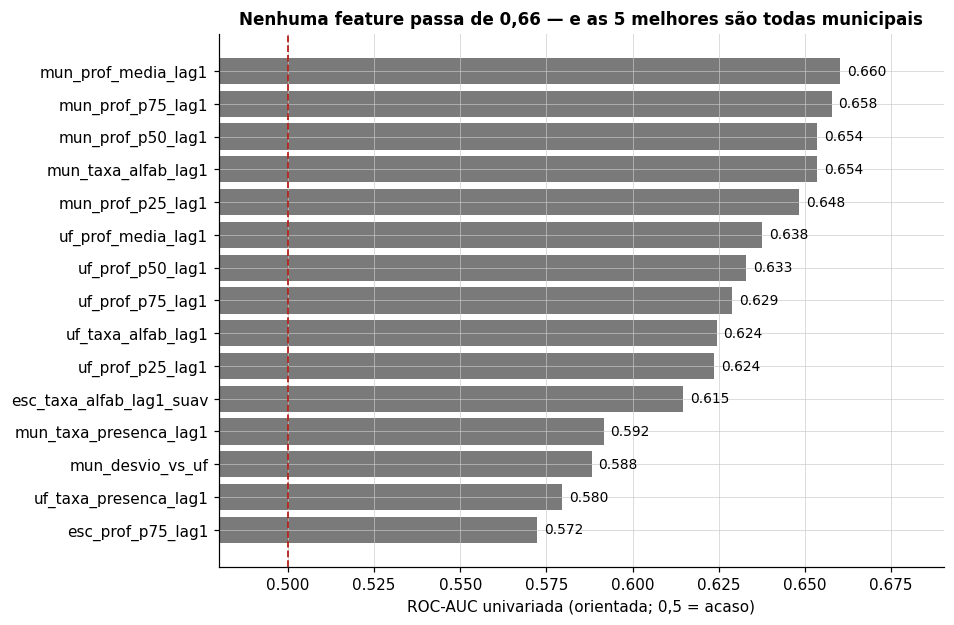

In [30]:
ranking_auc = eda.medir_auc_das_features(coorte, features_lag)   # a suavizada já está em features_lag
display(ranking_auc.round(4))

fig = eda.plotar_auc_das_features(
    ranking_auc.head(15), "Nenhuma feature passa de 0,66 — e as 5 melhores são todas municipais"
)
print(eda.salvar_figura(fig, "19_auc_univariada_features"))

**Achado 23.** As cinco melhores features univariadas são todas municipais: `mun_prof_media_lag1` com 0,660, `mun_prof_p75_lag1` com 0,658, `mun_prof_p50_lag1` com 0,654, `mun_taxa_alfab_lag1` com 0,654 e `mun_prof_p25_lag1` com 0,648. Depois vêm as de UF, entre 0,624 e 0,638, e só então a escola suavizada, com 0,615. A melhor feature puramente escolar é `esc_prof_p75_lag1`, com 0,572.

Nenhuma chega perto de 0,90, o que significa que não há vazamento. E nenhuma feature de porte ou dispersão passa de 0,55, o que já antecipa que o ganho do GBM sobre o baseline de uma variável será pequeno.

---
## Hipóteses analíticas que a EDA sustenta

Cada hipótese vem com o que a confirmaria ou derrubaria na modelagem. Hipótese sem critério de falseamento é opinião.

**H1. O contexto municipal de 2023 é o preditor dominante do risco individual em 2024.**
Base: persistência municipal de 0,645, IC [0,624; 0,664], e AUC univariada entre 0,648 e 0,660 nas cinco features municipais. *Falseável por:* uma família de features não municipal aparecer no topo do SHAP.

**H2. A escola não acrescenta sinal além do município.**
Base: `corr(desvio 2023, desvio 2024)` de 0,009 no total e -0,018 em escolas com 80 ou mais alunos; AUC da taxa escolar constante entre 0,554 e 0,560 nas faixas de porte; suavização monotônica em `k`. *Falseável por:* um modelo com features de escola superar, fora da amostra, o mesmo modelo sem elas por mais que o desvio entre folds.

**H3. O teto de performance é informacional, não amostral.**
Base: não há nenhuma variável sobre o aluno, `id_aluno` não é chave longitudinal com seus 0,12%, e a melhor feature isolada dá 0,660. *Falseável por:* a `learning_curve` ainda estar subindo no fim, o que indicaria falta de dados e não falta de variáveis.

**H4. O ganho do modelo sobre o baseline de uma variável será pequeno.**
Base: AUC de 0,654 da taxa municipal isolada contra 0,649 a 0,667 do GBM medido no diagnóstico inicial. *Falseável por:* o campeão superar 0,68 no teste agrupado por município. Se isso acontecer, a primeira hipótese a investigar é vazamento, não qualidade.

**H5. A ausência à prova é informativa e enviesa a taxa para cima.**
Base: 53,4% contra 74,6% de alfabetização entre o quintil de menor e o de maior presença municipal. *Falseável por:* `mun_taxa_presenca_lag1` não aparecer entre as features relevantes na interpretabilidade.

**H6. As metas não são alvo preditivo legítimo.**
Base: `corr(meta, taxa base)` de 0,976, metas idênticas entre os anos, meta 2030 igual a 80 para todos, e volatilidade municipal de 16,6pp contra um esforço mediano exigido de 1,9pp. *Falseável por:* nada nesta base, e é por isso que a recomendação é substituir a predição binária pelo gap aritmético e por probabilidade com incerteza.

---

## O que muda no plano, e o que se confirma

A medição confirmou o balanceamento do alvo (item 1), a `serie` constante (2), a desigualdade territorial (4), a nulidade estrutural (6), o tamanho das escolas (7), a persistência municipal (8 e 17), o corte determinístico em 743,0 (10), a cobertura do lag (12), o `id_aluno` reciclado (13), o prefixo territorial (14), as metas determinísticas (15), o sinal territorial e não escolar (16) e o viés de ausência (18).

Sete pontos contrariam ou corrigem o plano.

1. **O `caderno` não tem ICs sobrepostos** (item 3). A amplitude é de 1,75pp e a AUC é 0,506, então a conclusão prática não muda, mas o argumento correto passa a ser o tamanho do efeito, e não a sobreposição de intervalos. Com 1,85 milhão de linhas, "significante" deixou de significar alguma coisa.
2. **`preenchimento_caderno` é vazamento contemporâneo, não feature de engajamento** (item 5). São 936 alunos com alvo 0 por ausência de medida. A variável sai da lista de features e entra na matriz anti-leakage; as linhas saem do treino.
3. **Duas colunas constantes a mais** (item 2): `meta_alfabetizacao_brasil` e `percentual_participacao_brasil` são constantes dentro de 2024.
4. **A suavização da escola não é calibrável** (item 16). A AUC cresce monotonicamente com `k` até virar a taxa do município, então ela vira imputação documentada com `k` fixo, e não hiperparâmetro a otimizar por CV.
5. **`esc_desvio_vs_municipio` sai da lista de features** (item 16), com AUC de 0,457 e persistência do desvio igual a zero. É artefato de super-subtração, e como feature induziria interpretação causal errada na interpretabilidade.
6. **A colinearidade é exata, não apenas alta** (item 9). O IQR e os desvios são combinações lineares das demais colunas. O baseline linear precisa de um subconjunto podado, e o relatório de SHAP precisa agrupar por família.
7. **Números atualizados em relação ao diagnóstico inicial**, por diferença de população, já que ali se usou o microdado com `presenca = 1` e aqui a Gold: persistência municipal de 0,645 contra 0,636, evolução mediana de 2,1pp e 42,9% de municípios em queda contra 2,6pp e 41,2%, escola mediana com 32 alunos contra 34, e não atingimento da meta de 2024 em 45,7% contra 46,7%.

Para o desenho de validação, três consequências, todas confirmadas: agrupar por `id_municipio`, não fazer validação out-of-time ingênua, já que 2023 não tem lag e suas metas são 100% nulas, e fazer bootstrap reamostrando municípios em vez de alunos, porque a dependência intragrupo é forte. É o que os itens 4, 8 e 17 mostram.